In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Gerekli kütüphaneleri kur
!pip install pymupdf -q

import fitz  # PyMuPDF
import os
import shutil
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

print("Kurulum tamamlandı!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 65.2 MB/s eta 0:00:00
Kurulum tamamlandı!


In [ ]:
# Klasör yapısını oluştur
BASE_DIR = "/content/drive/MyDrive/SciDiagFuse"

RAW_PDFS = f"{BASE_DIR}/raw_pdfs"
EXTRACTED = f"{BASE_DIR}/extracted_images"

os.makedirs(f"{EXTRACTED}/meb_ornek", exist_ok=True)
os.makedirs(f"{EXTRACTED}/lgs_sinavlar", exist_ok=True)

print("Klasörler hazır!")
print(f"MEB PDF sayısı: {len(list(Path(f'{RAW_PDFS}/meb_ornek').glob('*.pdf')))}")
print(f"LGS PDF sayısı: {len(list(Path(f'{RAW_PDFS}/lgs_sinavlar').glob('*.pdf')))}")

Klasörler hazır!
MEB PDF sayısı: 7
LGS PDF sayısı: 8


In [ ]:
def extract_images_from_pdf(pdf_path, output_dir, min_width=80, min_height=80):
    """PDF'den görsel çıkarır ve kaydeder"""
    doc = fitz.open(pdf_path)
    pdf_name = Path(pdf_path).stem
    saved = 0

    for page_num in range(len(doc)):
        page = doc[page_num]
        image_list = page.get_images(full=True)

        for img_idx, img in enumerate(image_list):
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]
            image_ext = base_image["ext"]

            # PIL ile aç ve boyut kontrol et
            import io
            pil_img = Image.open(io.BytesIO(image_bytes))
            w, h = pil_img.size

            if w < min_width or h < min_height:
                continue

            # Kaydet
            filename = f"{pdf_name}_p{page_num+1}_img{img_idx+1}.{image_ext}"
            save_path = os.path.join(output_dir, filename)
            with open(save_path, "wb") as f:
                f.write(image_bytes)
            saved += 1

    doc.close()
    return saved

# MEB PDF'lerini işle
total = 0
for pdf_file in Path(f"{RAW_PDFS}/meb_ornek").glob("*.pdf"):
    count = extract_images_from_pdf(str(pdf_file), f"{EXTRACTED}/meb_ornek")
    print(f"{pdf_file.name}: {count} görsel")
    total += count
print(f"\nMEB toplam: {total} görsel")

Mevsimler ve İklim-unite1.pdf: 40 görsel
DNA ve Genetik Kod-unite2.pdf: 198 görsel
Basınç-unite3.pdf: 47 görsel
Madde ve Endüstri-unite4.pdf: 53 görsel
Basit Makineler-unite5.pdf: 11 görsel
Enerji Dönüşümleri ve Çevre Bilimi-unite6.pdf: 160 görsel
Elektrik Yükleri ve Elektrik Enerjisi-unite7.pdf: 5 görsel

MEB toplam: 514 görsel


In [ ]:
# LGS PDF'lerini işle
total_lgs = 0
for pdf_file in Path(f"{RAW_PDFS}/lgs_sinavlar").glob("*.pdf"):
    count = extract_images_from_pdf(str(pdf_file), f"{EXTRACTED}/lgs_sinavlar")
    print(f"{pdf_file.name}: {count} görsel")
    total_lgs += count
print(f"\nLGS toplam: {total_lgs} görsel")
print(f"Genel toplam: {total + total_lgs} görsel")

2020_FenBilimleri.pdf: 15 görsel
2018_FenBilimleri.pdf: 1 görsel
2019_FenBilimleri.pdf: 82 görsel
2021_FenBilimleri.pdf: 0 görsel
2022_FenBilimleri.pdf: 9 görsel
2023_FenBilimleri.pdf: 43 görsel
2024_FenBilimleri.pdf: 293 görsel
2025_FenBilimleri.pdf: 32 görsel

LGS toplam: 475 görsel
Genel toplam: 989 görsel


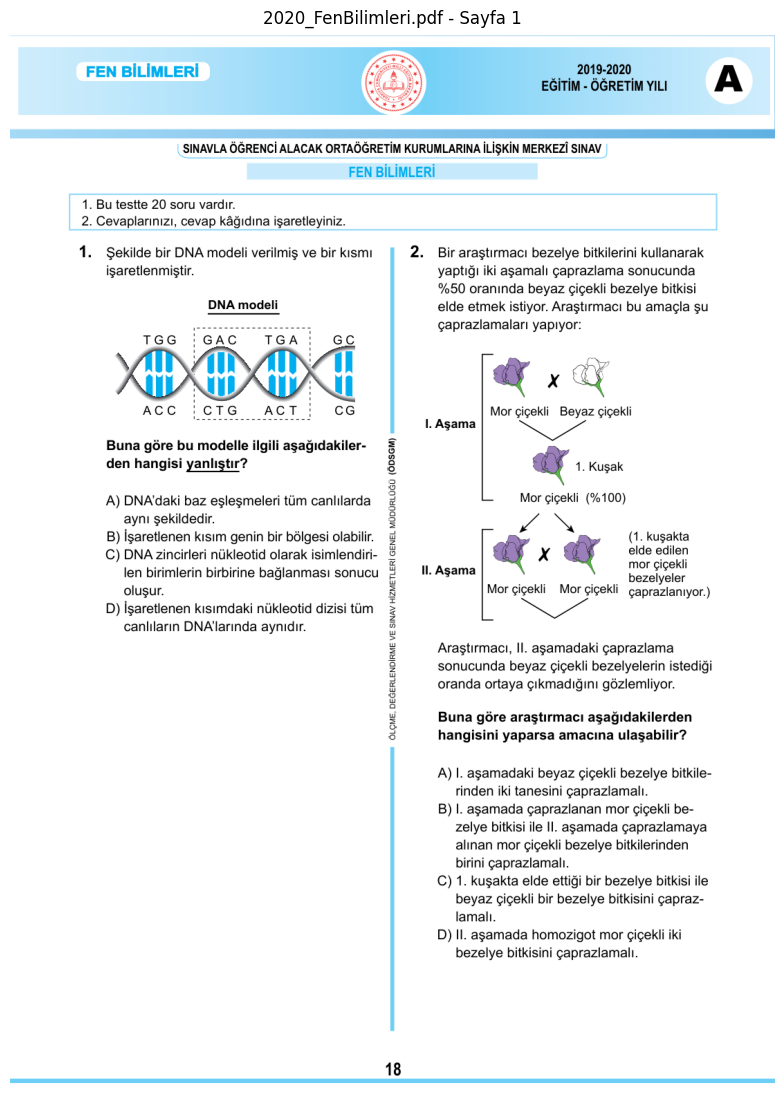

In [ ]:
# Bir LGS PDF'inin ilk sayfasını görüntüle
import fitz
import matplotlib.pyplot as plt
import numpy as np

# İlk LGS PDF'ini bul
pdf_files = list(Path(f"{RAW_PDFS}/lgs_sinavlar").glob("*.pdf"))
doc = fitz.open(str(pdf_files[0]))

# İlk sayfayı render et
page = doc[0]
mat = fitz.Matrix(2, 2)  # 2x zoom
pix = page.get_pixmap(matrix=mat)
img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)

plt.figure(figsize=(10, 14))
plt.imshow(img_array)
plt.axis('off')
plt.title(f"{pdf_files[0].name} - Sayfa 1")
plt.show()

doc.close()

In [ ]:
# Tüm PDF sayfalarını görüntüye çevir
PAGE_IMAGES_DIR = f"{BASE_DIR}/page_images"
os.makedirs(f"{PAGE_IMAGES_DIR}/meb_ornek", exist_ok=True)
os.makedirs(f"{PAGE_IMAGES_DIR}/lgs_sinavlar", exist_ok=True)

def pdf_to_images(pdf_path, output_dir, dpi=150):
    doc = fitz.open(str(pdf_path))
    pdf_name = Path(pdf_path).stem
    saved = 0
    for page_num in range(len(doc)):
        page = doc[page_num]
        mat = fitz.Matrix(dpi/72, dpi/72)
        pix = page.get_pixmap(matrix=mat)
        img_path = f"{output_dir}/{pdf_name}_sayfa{page_num+1}.png"
        pix.save(img_path)
        saved += 1
    doc.close()
    return saved

# MEB
total = 0
for pdf_file in Path(f"{RAW_PDFS}/meb_ornek").glob("*.pdf"):
    count = pdf_to_images(pdf_file, f"{PAGE_IMAGES_DIR}/meb_ornek")
    print(f"{pdf_file.name}: {count} sayfa")
    total += count

# LGS
for pdf_file in Path(f"{RAW_PDFS}/lgs_sinavlar").glob("*.pdf"):
    count = pdf_to_images(pdf_file, f"{PAGE_IMAGES_DIR}/lgs_sinavlar")
    print(f"{pdf_file.name}: {count} sayfa")
    total += count

print(f"\nToplam: {total} sayfa görüntüye çevrildi")

Mevsimler ve İklim-unite1.pdf: 34 sayfa
DNA ve Genetik Kod-unite2.pdf: 48 sayfa
Basınç-unite3.pdf: 44 sayfa
Madde ve Endüstri-unite4.pdf: 38 sayfa
Basit Makineler-unite5.pdf: 22 sayfa
Enerji Dönüşümleri ve Çevre Bilimi-unite6.pdf: 16 sayfa
Elektrik Yükleri ve Elektrik Enerjisi-unite7.pdf: 4 sayfa
2020_FenBilimleri.pdf: 14 sayfa
2018_FenBilimleri.pdf: 12 sayfa
2019_FenBilimleri.pdf: 13 sayfa
2021_FenBilimleri.pdf: 12 sayfa
2022_FenBilimleri.pdf: 15 sayfa
2023_FenBilimleri.pdf: 13 sayfa
2024_FenBilimleri.pdf: 13 sayfa
2025_FenBilimleri.pdf: 14 sayfa

Toplam: 312 sayfa görüntüye çevrildi


In [ ]:
!pip install label-studio -q
print("Label Studio kuruldu!")

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 50.3 MB/s eta 0:00:00
  

In [ ]:
import subprocess
import threading
import time

# Label Studio'yu arka planda başlat
def run_label_studio():
    subprocess.run([
        "label-studio", "start",
        "--no-browser",
        "--port", "8080"
    ])

thread = threading.Thread(target=run_label_studio)
thread.daemon = True
thread.start()

time.sleep(10)
print("Label Studio başlatıldı!")

# Colab'da dışarıdan erişim için
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8080)"))

Label Studio başlatıldı!
https://8080-m-s-kkb-use1c1-9pe5s3pn2f68-c.us-east1-1.prod.colab.dev


In [ ]:
!pip install pyngrok -q

from pyngrok import ngrok
import subprocess
import threading
import time

ngrok.set_auth_token("3ED4h0sgAgzWaVDqytpwDsvMXCm_4SSp52ams3XZD9er79kGR")

def run_ls():
    subprocess.Popen(["label-studio", "start", "--no-browser", "--port", "8080"])

thread = threading.Thread(target=run_ls)
thread.daemon = True
thread.start()
time.sleep(15)

public_url = ngrok.connect(8080)
print(f"Label Studio adresi: {public_url}")

Label Studio adresi: NgrokTunnel: "https://heavily-browse-audible.ngrok-free.dev" -> "http://localhost:8080"


In [ ]:
import time
time.sleep(20)
print("Hazır, linki tekrar dene!")

Hazır, linki tekrar dene!


In [ ]:
lgs_pages = list(Path(f"{PAGE_IMAGES_DIR}/lgs_sinavlar").glob("*.png"))
meb_pages = list(Path(f"{PAGE_IMAGES_DIR}/meb_ornek").glob("*.png"))
print(f"LGS sayfa sayısı: {len(lgs_pages)}")
print(f"MEB sayfa sayısı: {len(meb_pages)}")
print(f"Toplam: {len(lgs_pages) + len(meb_pages)}")

LGS sayfa sayısı: 106
MEB sayfa sayısı: 206
Toplam: 312


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/SciDiagFuse"
RAW_PDFS = f"{BASE_DIR}/raw_pdfs"
EXTRACTED = f"{BASE_DIR}/extracted_images"
PAGE_IMAGES_DIR = f"{BASE_DIR}/page_images"

print("Hazır!")

Mounted at /content/drive
Hazır!


In [ ]:
import json

# JSON dosyasını oku
json_path = f"{BASE_DIR}/annotations.json/project-1-at-2026-05-26-13-19-19d59a53.json"
with open(json_path, 'r', encoding='utf-8') as f:
    annotations = json.load(f)

print(f"Toplam görev sayısı: {len(annotations)}")

# İlk kaydı incele
print("\nİlk kayıt örneği:")
print(json.dumps(annotations[0], indent=2, ensure_ascii=False))

Toplam görev sayısı: 305

İlk kayıt örneği:
{
  "id": 16,
  "annotations": [
    {
      "id": 1,
      "completed_by": 1,
      "result": [
        {
          "original_width": 1182,
          "original_height": 1654,
          "image_rotation": 0,
          "value": {
            "x": 10.69311521750277,
            "y": 12.648221343873518,
            "width": 64.15869130501663,
            "height": 16.073781291172594,
            "rotation": 0,
            "rectanglelabels": [
              "C7_Tablo_Matris"
            ]
          },
          "id": "GkPiIt9tnJ",
          "from_name": "label",
          "to_name": "image",
          "type": "rectanglelabels",
          "origin": "manual"
        }
      ],
      "was_cancelled": false,
      "ground_truth": false,
      "created_at": "2026-05-25T10:15:00.276706Z",
      "updated_at": "2026-05-25T10:15:00.276706Z",
      "draft_created_at": "2026-05-25T10:14:56.927909Z",
      "lead_time": 108.959,
      "prediction": {},
      "

In [ ]:
import os
from PIL import Image
from pathlib import Path

# Kırpılmış görseller için klasör
CROPS_DIR = f"{BASE_DIR}/cropped_images"
os.makedirs(CROPS_DIR, exist_ok=True)

crop_count = 0
skipped = 0
dataset = []  # görsel yolu + etiket listesi

for task in annotations:
    # Dosya adını al
    file_upload = task.get("file_upload", "")
    # UUID kısmını kaldır
    filename = file_upload.split("-", 1)[1] if "-" in file_upload else file_upload

    # Sayfanın hangi klasörde olduğunu bul
    img_path = None
    for folder in ["lgs_sinavlar", "meb_ornek"]:
        candidate = f"{PAGE_IMAGES_DIR}/{folder}/{filename}"
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        skipped += 1
        continue

    # Görseli aç
    img = Image.open(img_path)
    w, h = img.size

    # Her annotation için kırp
    for ann in task.get("annotations", []):
        for result in ann.get("result", []):
            value = result.get("value", {})
            labels = value.get("rectanglelabels", [])
            if not labels:
                continue

            label = labels[0]

            # Koordinatları piksel'e çevir
            x = value["x"] / 100 * w
            y = value["y"] / 100 * h
            bw = value["width"] / 100 * w
            bh = value["height"] / 100 * h

            # Kırp
            crop = img.crop((x, y, x + bw, y + bh))

            # Kaydet
            crop_name = f"{label}_{crop_count:04d}.png"
            crop_path = f"{CROPS_DIR}/{crop_name}"
            crop.save(crop_path)

            dataset.append({"image": crop_path, "label": label})
            crop_count += 1

print(f"Toplam kırpılan görsel: {crop_count}")
print(f"Bulunamayan dosya: {skipped}")

# Etiket dağılımı
from collections import Counter
label_counts = Counter(d["label"] for d in dataset)
for label, count in sorted(label_counts.items()):
    print(f"{label}: {count}")

Toplam kırpılan görsel: 239
Bulunamayan dosya: 156
C1_Kuvvet_Hareket: 69
C2_Grafik_Chart: 15
C3_Molekuler_Kimyasal: 14
C4_Deney_Duzenegi: 57
C5_Biyolojik_Anatomik: 26
C6_Astronomi_YerBilimi: 9
C7_Tablo_Matris: 15
Gorsel_Yok: 34


In [ ]:
# Bulunamayan dosyaların isimlerine bakalım
for task in annotations[:5]:
    file_upload = task.get("file_upload", "")
    filename = file_upload.split("-", 1)[1] if "-" in file_upload else file_upload
    print(f"JSON'daki isim: {file_upload}")
    print(f"Aranan isim: {filename}")
    print()

# Klasördeki gerçek dosya isimlerine bakalım
lgs_files = list(Path(f"{PAGE_IMAGES_DIR}/lgs_sinavlar").glob("*.png"))[:5]
print("Klasördeki dosyalar:")
for f in lgs_files:
    print(f.name)

JSON'daki isim: 181d9299-2019_FenBilimleri_sayfa10.png
Aranan isim: 2019_FenBilimleri_sayfa10.png

JSON'daki isim: 42481d0c-2019_FenBilimleri_sayfa11.png
Aranan isim: 2019_FenBilimleri_sayfa11.png

JSON'daki isim: db61442f-2019_FenBilimleri_sayfa12.png
Aranan isim: 2019_FenBilimleri_sayfa12.png

JSON'daki isim: 1618d10c-2019_FenBilimleri_sayfa13.png
Aranan isim: 2019_FenBilimleri_sayfa13.png

JSON'daki isim: a5c86118-2018_FenBilimleri_sayfa1.png
Aranan isim: 2018_FenBilimleri_sayfa1.png

Klasördeki dosyalar:
2020_FenBilimleri_sayfa1.png
2020_FenBilimleri_sayfa2.png
2020_FenBilimleri_sayfa3.png
2020_FenBilimleri_sayfa4.png
2020_FenBilimleri_sayfa5.png


In [ ]:
# Tüm PNG dosyalarını bul
all_files = {}
for folder in ["lgs_sinavlar", "meb_ornek"]:
    for f in Path(f"{PAGE_IMAGES_DIR}/{folder}").glob("*.png"):
        all_files[f.name] = str(f)

print(f"Toplam bulunan dosya: {len(all_files)}")

# Kaç tanesi eşleşmiyor
missing = []
for task in annotations:
    file_upload = task.get("file_upload", "")
    filename = file_upload.split("-", 1)[1] if "-" in file_upload else file_upload
    if filename not in all_files:
        missing.append(filename)

print(f"Eşleşmeyen dosya: {len(missing)}")
print("\nİlk 5 eşleşmeyen:")
for m in missing[:5]:
    print(m)

Toplam bulunan dosya: 312
Eşleşmeyen dosya: 199

İlk 5 eşleşmeyen:
Basınç-unite3_sayfa31.png
Basınç-unite3_sayfa32.png
Basınç-unite3_sayfa33.png
Basınç-unite3_sayfa34.png
Basınç-unite3_sayfa35.png


In [ ]:
# MEB dosya isimlerine bakalım
meb_files = list(Path(f"{PAGE_IMAGES_DIR}/meb_ornek").glob("*.png"))[:10]
print("MEB klasöründeki dosyalar:")
for f in meb_files:
    print(f.name)

MEB klasöründeki dosyalar:
Mevsimler ve İklim-unite1_sayfa1.png
Mevsimler ve İklim-unite1_sayfa2.png
Mevsimler ve İklim-unite1_sayfa3.png
Mevsimler ve İklim-unite1_sayfa4.png
Mevsimler ve İklim-unite1_sayfa5.png
Mevsimler ve İklim-unite1_sayfa6.png
Mevsimler ve İklim-unite1_sayfa7.png
Mevsimler ve İklim-unite1_sayfa8.png
Mevsimler ve İklim-unite1_sayfa9.png
Mevsimler ve İklim-unite1_sayfa10.png


In [ ]:
import unicodedata

def normalize_filename(name):
    # Türkçe karakterleri ve boşlukları normalize et
    name = name.replace(" ", "%20")
    return name

# Tüm PNG dosyalarını normalize isimle indeksle
all_files_normalized = {}
for folder in ["lgs_sinavlar", "meb_ornek"]:
    for f in Path(f"{PAGE_IMAGES_DIR}/{folder}").glob("*.png"):
        all_files_normalized[f.name] = str(f)
        all_files_normalized[normalize_filename(f.name)] = str(f)

# JSON'daki eşleşmeyen dosyaları tekrar dene
found = 0
still_missing = []
for task in annotations:
    file_upload = task.get("file_upload", "")
    filename = file_upload.split("-", 1)[1] if "-" in file_upload else file_upload
    if filename in all_files_normalized:
        found += 1
    else:
        still_missing.append(filename)

print(f"Bulunan: {found}")
print(f"Hâlâ bulunamayan: {len(still_missing)}")
print("\nİlk 5:")
for m in still_missing[:5]:
    print(repr(m))

Bulunan: 106
Hâlâ bulunamayan: 199

İlk 5:
'Basınç-unite3_sayfa31.png'
'Basınç-unite3_sayfa32.png'
'Basınç-unite3_sayfa33.png'
'Basınç-unite3_sayfa34.png'
'Basınç-unite3_sayfa35.png'


In [ ]:
# Klasördeki Basınç dosyalarını bul
basinc_files = [f.name for f in Path(f"{PAGE_IMAGES_DIR}/meb_ornek").glob("*.png") if "Bas" in f.name]
print("Klasördeki Basınç dosyaları:")
for f in basinc_files[:5]:
    print(repr(f))

# JSON'daki Basınç dosyaları
print("\nJSON'daki Basınç dosyaları:")
for task in annotations:
    filename = task.get("file_upload", "").split("-", 1)[1]
    if "Bas" in filename:
        print(repr(filename))
        break

Klasördeki Basınç dosyaları:
'Basınç-unite3_sayfa1.png'
'Basınç-unite3_sayfa2.png'
'Basınç-unite3_sayfa3.png'
'Basınç-unite3_sayfa4.png'
'Basınç-unite3_sayfa5.png'

JSON'daki Basınç dosyaları:
'Basınç-unite3_sayfa31.png'


In [ ]:
# Klasörde kaç sayfa var Basınç için
basinc_files = sorted([f.name for f in Path(f"{PAGE_IMAGES_DIR}/meb_ornek").glob("*.png") if "Bas" in f.name])
print(f"Klasörde Basınç sayfa sayısı: {len(basinc_files)}")
print("Son 5:", basinc_files[-5:])

# JSON'da kaç tane var
json_basinc = []
for task in annotations:
    filename = task.get("file_upload", "").split("-", 1)[1]
    if "Bas" in filename:
        json_basinc.append(filename)
print(f"\nJSON'da Basınç sayfa sayısı: {len(json_basinc)}")
print("İlk 5:", sorted(json_basinc)[:5])

Klasörde Basınç sayfa sayısı: 66
Son 5: ['Basınç-unite3_sayfa5.png', 'Basınç-unite3_sayfa6.png', 'Basınç-unite3_sayfa7.png', 'Basınç-unite3_sayfa8.png', 'Basınç-unite3_sayfa9.png']

JSON'da Basınç sayfa sayısı: 64
İlk 5: ['Basit_Makineler-unite5_sayfa10.png', 'Basit_Makineler-unite5_sayfa11.png', 'Basit_Makineler-unite5_sayfa12.png', 'Basit_Makineler-unite5_sayfa13.png', 'Basit_Makineler-unite5_sayfa14.png']


In [ ]:
# Klasördeki tüm MEB dosyalarını ve JSON'dakileri karşılaştır
klasor_isimleri = set(f.name for f in Path(f"{PAGE_IMAGES_DIR}/meb_ornek").glob("*.png"))
json_isimleri = set()
for task in annotations:
    filename = task.get("file_upload", "").split("-", 1)[1]
    json_isimleri.add(filename)

print("Klasör örnek:", list(klasor_isimleri)[:3])
print("JSON örnek:", list(json_isimleri)[:3])

Klasör örnek: ['Enerji Dönüşümleri ve Çevre Bilimi-unite6_sayfa3.png', 'Basınç-unite3_sayfa24.png', 'Enerji Dönüşümleri ve Çevre Bilimi-unite6_sayfa5.png']
JSON örnek: ['2019_FenBilimleri_sayfa12.png', '2024_FenBilimleri_sayfa6.png', 'Mevsimler_ve_İklim-unite1_sayfa11.png']


In [ ]:
# Klasör dosyalarını hem orijinal hem alt çizgili versiyonla indeksle
all_files_fixed = {}
for folder in ["lgs_sinavlar", "meb_ornek"]:
    for f in Path(f"{PAGE_IMAGES_DIR}/{folder}").glob("*.png"):
        # Orijinal isim
        all_files_fixed[f.name] = str(f)
        # Boşlukları alt çizgiye çevir
        alt_cizgili = f.name.replace(" ", "_")
        all_files_fixed[alt_cizgili] = str(f)

print(f"Toplam indekslenen: {len(all_files_fixed)}")

# Şimdi eşleşme kontrolü
found = 0
missing = []
for task in annotations:
    filename = task.get("file_upload", "").split("-", 1)[1]
    if filename in all_files_fixed:
        found += 1
    else:
        missing.append(filename)

print(f"Bulunan: {found}")
print(f"Bulunamayan: {len(missing)}")
if missing:
    print("İlk 3:", missing[:3])

Toplam indekslenen: 474
Bulunan: 174
Bulunamayan: 131
İlk 3: ['Basınç-unite3_sayfa31.png', 'Basınç-unite3_sayfa32.png', 'Basınç-unite3_sayfa33.png']


In [ ]:
# Basınç dosyalarının numaralarını listele
basinc_klasor = sorted([f.name for f in Path(f"{PAGE_IMAGES_DIR}/meb_ornek").glob("*.png") if "Bas" in f.name and "unite3" in f.name])
print(f"Klasörde Basınç sayfa sayısı: {len(basinc_klasor)}")
print("Tüm sayfalar:", basinc_klasor)

Klasörde Basınç sayfa sayısı: 44
Tüm sayfalar: ['Basınç-unite3_sayfa1.png', 'Basınç-unite3_sayfa10.png', 'Basınç-unite3_sayfa11.png', 'Basınç-unite3_sayfa12.png', 'Basınç-unite3_sayfa13.png', 'Basınç-unite3_sayfa14.png', 'Basınç-unite3_sayfa15.png', 'Basınç-unite3_sayfa16.png', 'Basınç-unite3_sayfa17.png', 'Basınç-unite3_sayfa18.png', 'Basınç-unite3_sayfa19.png', 'Basınç-unite3_sayfa2.png', 'Basınç-unite3_sayfa20.png', 'Basınç-unite3_sayfa21.png', 'Basınç-unite3_sayfa22.png', 'Basınç-unite3_sayfa23.png', 'Basınç-unite3_sayfa24.png', 'Basınç-unite3_sayfa25.png', 'Basınç-unite3_sayfa26.png', 'Basınç-unite3_sayfa27.png', 'Basınç-unite3_sayfa28.png', 'Basınç-unite3_sayfa29.png', 'Basınç-unite3_sayfa3.png', 'Basınç-unite3_sayfa30.png', 'Basınç-unite3_sayfa31.png', 'Basınç-unite3_sayfa32.png', 'Basınç-unite3_sayfa33.png', 'Basınç-unite3_sayfa34.png', 'Basınç-unite3_sayfa35.png', 'Basınç-unite3_sayfa36.png', 'Basınç-unite3_sayfa37.png', 'Basınç-unite3_sayfa38.p

In [ ]:
# Encoding sorununu çöz - tüm dosyaları normalize et
import unicodedata

def normalize(s):
    return unicodedata.normalize('NFC', s)

all_files_fixed2 = {}
for folder in ["lgs_sinavlar", "meb_ornek"]:
    for f in Path(f"{PAGE_IMAGES_DIR}/{folder}").glob("*.png"):
        all_files_fixed2[normalize(f.name)] = str(f)
        all_files_fixed2[normalize(f.name.replace(" ", "_"))] = str(f)

# Test
found = 0
missing = []
for task in annotations:
    filename = normalize(task.get("file_upload", "").split("-", 1)[1])
    if filename in all_files_fixed2:
        found += 1
    else:
        missing.append(filename)

print(f"Bulunan: {found}")
print(f"Bulunamayan: {len(missing)}")
if missing:
    print("İlk 3:", missing[:3])

Bulunan: 305
Bulunamayan: 0


In [ ]:
from PIL import Image
from pathlib import Path
import os

CROPS_DIR = f"{BASE_DIR}/cropped_images"
os.makedirs(CROPS_DIR, exist_ok=True)

crop_count = 0
dataset = []

for task in annotations:
    file_upload = task.get("file_upload", "")
    filename = normalize(file_upload.split("-", 1)[1] if "-" in file_upload else file_upload)

    if filename not in all_files_fixed2:
        continue

    img_path = all_files_fixed2[filename]
    img = Image.open(img_path)
    w, h = img.size

    for ann in task.get("annotations", []):
        for result in ann.get("result", []):
            value = result.get("value", {})
            labels = value.get("rectanglelabels", [])
            if not labels:
                continue

            label = labels[0]
            if label == "Gorsel_Yok":
                continue

            x = value["x"] / 100 * w
            y = value["y"] / 100 * h
            bw = value["width"] / 100 * w
            bh = value["height"] / 100 * h

            crop = img.crop((x, y, x + bw, y + bh))
            crop_name = f"{label}_{crop_count:04d}.png"
            crop_path = f"{CROPS_DIR}/{crop_name}"
            crop.save(crop_path)

            dataset.append({"image": crop_path, "label": label})
            crop_count += 1

print(f"Toplam kırpılan görsel: {crop_count}")

from collections import Counter
label_counts = Counter(d["label"] for d in dataset)
for label, count in sorted(label_counts.items()):
    print(f"{label}: {count}")

Toplam kırpılan görsel: 499
C1_Kuvvet_Hareket: 119
C2_Grafik_Chart: 57
C3_Molekuler_Kimyasal: 25
C4_Deney_Duzenegi: 103
C5_Biyolojik_Anatomik: 85
C6_Astronomi_YerBilimi: 50
C7_Tablo_Matris: 60


In [ ]:
import pandas as pd

df = pd.DataFrame(dataset)
csv_path = f"{BASE_DIR}/dataset.csv"
df.to_csv(csv_path, index=False)
print(f"Dataset kaydedildi: {csv_path}")
print(df["label"].value_counts())

Dataset kaydedildi: /content/drive/MyDrive/SciDiagFuse/dataset.csv
label
C1_Kuvvet_Hareket         119
C4_Deney_Duzenegi         103
C5_Biyolojik_Anatomik      85
C7_Tablo_Matris            60
C2_Grafik_Chart            57
C6_Astronomi_YerBilimi     50
C3_Molekuler_Kimyasal      25
Name: count, dtype: int64


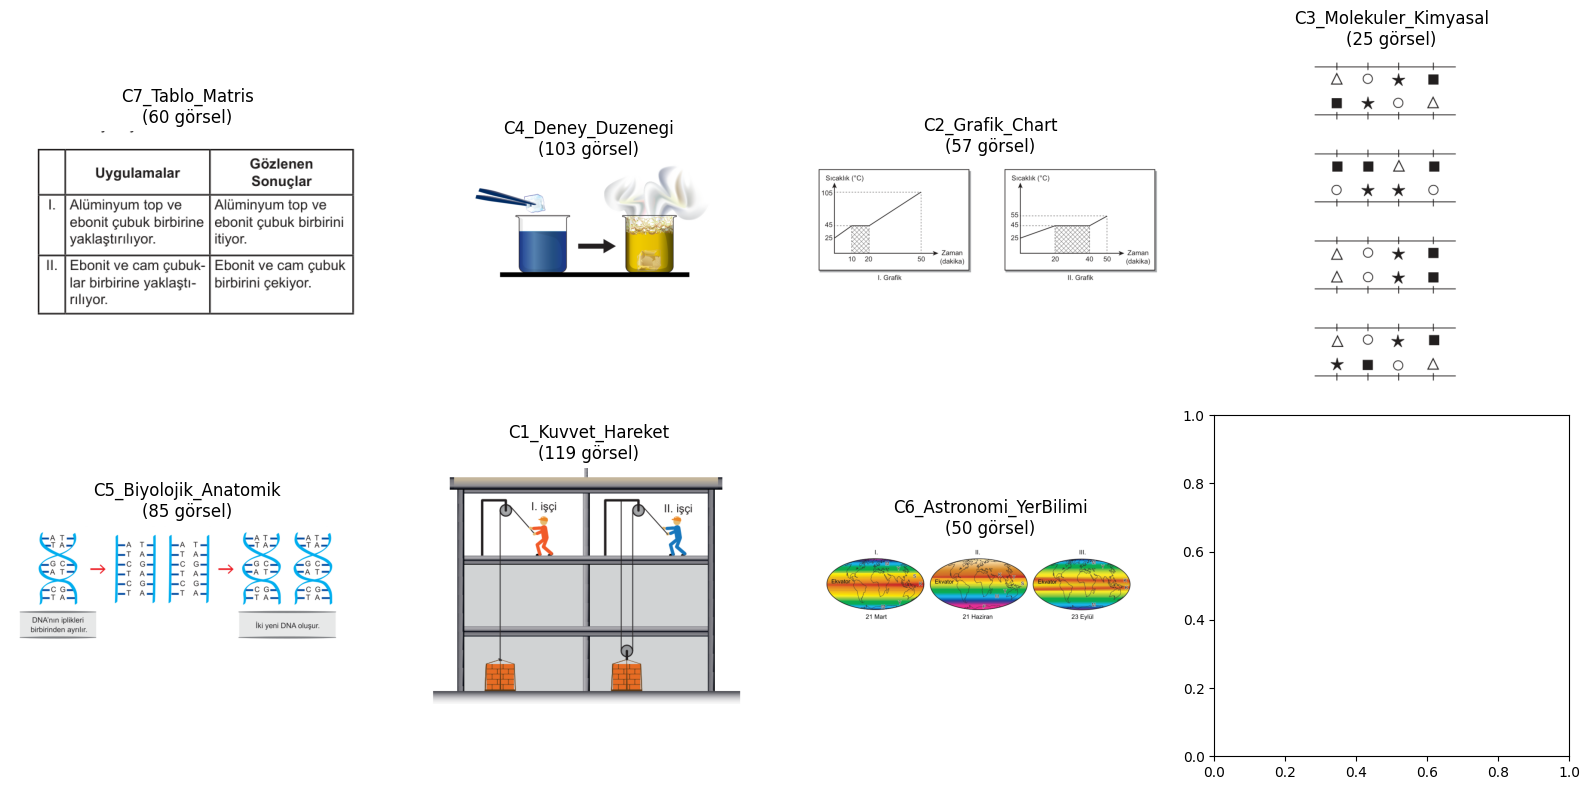

In [ ]:
import matplotlib.pyplot as plt
import random

# Her kategoriden bir örnek göster
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (label, count) in enumerate(label_counts.items()):
    # Bu kategoriden rastgele bir görsel seç
    samples = [d for d in dataset if d["label"] == label]
    sample = random.choice(samples)
    img = Image.open(sample["image"])
    axes[i].imshow(img)
    axes[i].set_title(f"{label}\n({count} görsel)")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Colab local diske kaydet - çok daha hızlı
AUGMENTED_DIR = "/content/augmented_images"
os.makedirs(AUGMENTED_DIR, exist_ok=True)

augmented_dataset = list(dataset)
TARGET = 100

for label in label_counts:
    if label == "Gorsel_Yok":
        continue

    samples = [d for d in dataset if d["label"] == label]
    current = len(samples)
    needed = max(0, TARGET - current)
    print(f"{label}: {current} → {current + needed} (eklenecek: {needed})")

    aug_count = 0
    while aug_count < needed:
        sample = random.choice(samples)
        img = cv2.imread(sample["image"])
        if img is None:
            continue
        augmented = transform(image=img)["image"]
        aug_name = f"{label}_aug_{aug_count:04d}.png"
        aug_path = f"{AUGMENTED_DIR}/{aug_name}"
        cv2.imwrite(aug_path, augmented)
        augmented_dataset.append({"image": aug_path, "label": label})
        aug_count += 1

print(f"\nToplam dataset: {len(augmented_dataset)}")
from collections import Counter
counts = Counter(d["label"] for d in augmented_dataset)
for l, c in sorted(counts.items()):
    print(f"{l}: {c}")

C7_Tablo_Matris: 60 → 100 (eklenecek: 40)
C4_Deney_Duzenegi: 103 → 103 (eklenecek: 0)
C2_Grafik_Chart: 57 → 100 (eklenecek: 43)
C3_Molekuler_Kimyasal: 25 → 100 (eklenecek: 75)
C5_Biyolojik_Anatomik: 85 → 100 (eklenecek: 15)
C1_Kuvvet_Hareket: 119 → 119 (eklenecek: 0)
C6_Astronomi_YerBilimi: 50 → 100 (eklenecek: 50)

Toplam dataset: 722
C1_Kuvvet_Hareket: 119
C2_Grafik_Chart: 100
C3_Molekuler_Kimyasal: 100
C4_Deney_Duzenegi: 103
C5_Biyolojik_Anatomik: 100
C6_Astronomi_YerBilimi: 100
C7_Tablo_Matris: 100


In [ ]:
import pandas as pd

df_augmented = pd.DataFrame(augmented_dataset)
csv_path = f"{BASE_DIR}/dataset_augmented.csv"
df_augmented.to_csv(csv_path, index=False)
print(f"Dataset kaydedildi!")
print(df_augmented["label"].value_counts())

Dataset kaydedildi!
label
C1_Kuvvet_Hareket         119
C4_Deney_Duzenegi         103
C7_Tablo_Matris           100
C2_Grafik_Chart           100
C3_Molekuler_Kimyasal     100
C5_Biyolojik_Anatomik     100
C6_Astronomi_YerBilimi    100
Name: count, dtype: int64


In [ ]:
from pathlib import Path

lgs_pages = list(Path(f"{PAGE_IMAGES_DIR}/lgs_sinavlar").glob("*.png"))
meb_pages = list(Path(f"{PAGE_IMAGES_DIR}/meb_ornek").glob("*.png"))
print(f"LGS: {len(lgs_pages)}, MEB: {len(meb_pages)}")

LGS: 106, MEB: 206


In [ ]:
!apt-get install -y tesseract-ocr tesseract-ocr-tur -q
!pip install pytesseract -q

import pytesseract
from PIL import Image

# Test - bir sayfadan metin çıkar
test_img = Image.open(str(lgs_pages[0]))
text = pytesseract.image_to_string(test_img, lang='tur')
print(text[:500])

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-tur is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
 

FEN BİLİMLERİ

A

 

(SINAVLA ÖĞRENCİ ALACAK ORTAÖĞRETİM KURUMLARINA İLİŞKİN MERKEZİ SINAV |

 

 

 

 

 

FEN BİLİMLERİ
1. Bu testte 20 soru vardır.
2. Cevaplarınızı, cevap kâğıdına işaretleyiniz.
1. Şekilde bir DNA modeli verilmiş ve bir kısmı 2. Bir araştırmacı bezelye bitkilerini kullanarak
işaretlenmiştir. yaptığı iki aşamalı çaprazlama sonucunda
9050 oranında beyaz çiçekli bezelye bitkisi
DNA modeli elde etmek istiyor. Araştırmacı bu amaçla şu

çaprazlamaları yapıyor:

MÜ

Mor çiçekli


In [ ]:
import pytesseract
from PIL import Image
import json

ocr_results = {}
all_pages = lgs_pages + meb_pages

print(f"Toplam sayfa: {len(all_pages)}")

for i, page_path in enumerate(all_pages):
    filename = page_path.name
    img = Image.open(str(page_path))
    text = pytesseract.image_to_string(img, lang='tur')
    ocr_results[filename] = text.strip()

    if (i+1) % 20 == 0:
        print(f"{i+1}/{len(all_pages)} tamamlandı...")

# Kaydet
ocr_path = f"{BASE_DIR}/ocr_texts.json"
with open(ocr_path, 'w', encoding='utf-8') as f:
    json.dump(ocr_results, f, ensure_ascii=False, indent=2)

print(f"\nOCR tamamlandı! {len(ocr_results)} sayfa işlendi.")

Toplam sayfa: 312
20/312 tamamlandı...
40/312 tamamlandı...
60/312 tamamlandı...
80/312 tamamlandı...
100/312 tamamlandı...
120/312 tamamlandı...
140/312 tamamlandı...
160/312 tamamlandı...
180/312 tamamlandı...
200/312 tamamlandı...
220/312 tamamlandı...
240/312 tamamlandı...
260/312 tamamlandı...
280/312 tamamlandı...
300/312 tamamlandı...

OCR tamamlandı! 312 sayfa işlendi.


In [ ]:
import unicodedata

# OCR sonuçlarını yükle
with open(f"{BASE_DIR}/ocr_texts.json", 'r', encoding='utf-8') as f:
    ocr_results = json.load(f)

# JSON'dan sayfa-görsel eşleşmesini oluştur
page_to_label = {}
for task in annotations:
    file_upload = task.get("file_upload", "")
    filename = unicodedata.normalize('NFC', file_upload.split("-", 1)[1] if "-" in file_upload else file_upload)
    filename_space = filename.replace("_", " ")

    for ann in task.get("annotations", []):
        for result in ann.get("result", []):
            labels = result.get("value", {}).get("rectanglelabels", [])
            if labels and labels[0] != "Gorsel_Yok":
                if filename not in page_to_label:
                    page_to_label[filename] = []
                page_to_label[filename].append(labels[0])

# Final dataset oluştur
final_dataset = []
for item in augmented_dataset:
    img_path = item["image"]
    label = item["label"]

    # Hangi sayfadan geldiğini bul
    img_name = Path(img_path).name
    page_text = ""

    for page_name, text in ocr_results.items():
        norm_page = unicodedata.normalize('NFC', page_name)
        if label in page_name or any(label in l for l in page_to_label.get(norm_page, [])):
            page_text = text
            break

    final_dataset.append({
        "image": img_path,
        "label": label,
        "text": page_text
    })

# CSV olarak kaydet
df_final = pd.DataFrame(final_dataset)
df_final.to_csv(f"{BASE_DIR}/dataset_final.csv", index=False)
print(f"Final dataset: {len(df_final)} örnek")
print(f"Metin olan: {(df_final['text'] != '').sum()}")
print(f"Metin olmayan: {(df_final['text'] == '').sum()}")

Final dataset: 722 örnek
Metin olan: 722
Metin olmayan: 0


In [ ]:
from sklearn.model_selection import train_test_split

# Önce label'ları sayısal yapıyoruz
label_to_idx = {
    'C1_Kuvvet_Hareket': 0,
    'C2_Grafik_Chart': 1,
    'C3_Molekuler_Kimyasal': 2,
    'C4_Deney_Duzenegi': 3,
    'C5_Biyolojik_Anatomik': 4,
    'C6_Astronomi_YerBilimi': 5,
    'C7_Tablo_Matris': 6
}

df_final['label_idx'] = df_final['label'].map(label_to_idx)

# 70/15/15 split
train_df, temp_df = train_test_split(df_final, test_size=0.30,
                                      stratify=df_final['label_idx'],
                                      random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50,
                                    stratify=temp_df['label_idx'],
                                    random_state=42)

print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

# Kaydet
train_df.to_csv(f"{BASE_DIR}/train.csv", index=False)
val_df.to_csv(f"{BASE_DIR}/val.csv", index=False)
test_df.to_csv(f"{BASE_DIR}/test.csv", index=False)
print("Split kaydedildi!")

Train: 505
Validation: 108
Test: 109
Split kaydedildi!


In [ ]:
!pip install timm -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd

# GPU var mı kontrol et
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cpu


In [ ]:
!pip install timm -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd

# GPU var mı kontrol et
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

BASE_DIR = "/content/drive/MyDrive/SciDiagFuse"
PAGE_IMAGES_DIR = f"{BASE_DIR}/page_images"

# CSV'leri yükle
train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
val_df = pd.read_csv(f"{BASE_DIR}/val.csv")
test_df = pd.read_csv(f"{BASE_DIR}/test.csv")

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Mounted at /content/drive
Train: 505, Val: 108, Test: 109


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# Dataset sınıfı
class ImageOnlyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = int(row['label_idx'])
        return img, label

# Transform
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# DataLoader
train_dataset = ImageOnlyDataset(train_df, train_transform)
val_dataset = ImageOnlyDataset(val_df, val_transform)
test_dataset = ImageOnlyDataset(test_df, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Dataset hazır!")
print(f"Train batch sayısı: {len(train_loader)}")

Dataset hazır!
Train batch sayısı: 16


In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-4):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_f1 = 0
    patience = 5
    patience_counter = 0

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                outputs = model(imgs)
                preds = outputs.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')
        val_acc = accuracy_score(all_labels, all_preds)
        scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.3f} | Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f"{BASE_DIR}/best_resnet50.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping!")
                break

    return best_val_f1

# ResNet-50 modeli
resnet = models.resnet50(pretrained=True)
resnet.fc = nn.Linear(2048, 7)

print("ResNet-50 eğitimi başlıyor...")
best_f1 = train_model(resnet, train_loader, val_loader, epochs=20)
print(f"\nEn iyi Val F1: {best_f1:.3f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 34.5MB/s]


ResNet-50 eğitimi başlıyor...


FileNotFoundError: [Errno 2] No such file or directory: '/content/augmented_images/C6_Astronomi_YerBilimi_aug_0016.png'

In [ ]:
import albumentations as A
import cv2
import random
from collections import Counter

# Augmentation pipeline
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.5),
    A.GaussNoise(p=0.3),
])

AUGMENTED_DIR = f"{BASE_DIR}/augmented_images"
os.makedirs(AUGMENTED_DIR, exist_ok=True)

# Orijinal dataset'i yükle
import json
import unicodedata

df_original = pd.read_csv(f"{BASE_DIR}/dataset.csv")
dataset = df_original.to_dict('records')
label_counts = Counter(d["label"] for d in dataset)

augmented_dataset = list(dataset)
TARGET = 100

for label in label_counts:
    if label == "Gorsel_Yok":
        continue
    samples = [d for d in dataset if d["label"] == label]
    current = len(samples)
    needed = max(0, TARGET - current)
    print(f"{label}: {current} → {current + needed}")

    aug_count = 0
    while aug_count < needed:
        sample = random.choice(samples)
        img = cv2.imread(sample["image"])
        if img is None:
            continue
        augmented = transform(image=img)["image"]
        aug_name = f"{label}_aug_{aug_count:04d}.png"
        aug_path = f"{AUGMENTED_DIR}/{aug_name}"
        cv2.imwrite(aug_path, augmented)
        augmented_dataset.append({"image": aug_path, "label": label})
        aug_count += 1

print(f"\nToplam: {len(augmented_dataset)}")

C7_Tablo_Matris: 60 → 100
C4_Deney_Duzenegi: 103 → 103
C2_Grafik_Chart: 57 → 100
C3_Molekuler_Kimyasal: 25 → 100
C5_Biyolojik_Anatomik: 85 → 100
C1_Kuvvet_Hareket: 119 → 119
C6_Astronomi_YerBilimi: 50 → 100

Toplam: 722


In [ ]:
from sklearn.model_selection import train_test_split

label_to_idx = {
    'C1_Kuvvet_Hareket': 0,
    'C2_Grafik_Chart': 1,
    'C3_Molekuler_Kimyasal': 2,
    'C4_Deney_Duzenegi': 3,
    'C5_Biyolojik_Anatomik': 4,
    'C6_Astronomi_YerBilimi': 5,
    'C7_Tablo_Matris': 6
}

# OCR metinlerini yükle
with open(f"{BASE_DIR}/ocr_texts.json", 'r', encoding='utf-8') as f:
    ocr_results = json.load(f)

# Augmented dataset'e metin ekle
for item in augmented_dataset:
    item['label_idx'] = label_to_idx[item['label']]
    item['text'] = ""
    for page_name, text in ocr_results.items():
        if item['label'] in page_name:
            item['text'] = text
            break

df_final = pd.DataFrame(augmented_dataset)

# Split
train_df, temp_df = train_test_split(df_final, test_size=0.30, stratify=df_final['label_idx'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label_idx'], random_state=42)

train_df.to_csv(f"{BASE_DIR}/train.csv", index=False)
val_df.to_csv(f"{BASE_DIR}/val.csv", index=False)
test_df.to_csv(f"{BASE_DIR}/test.csv", index=False)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 505, Val: 108, Test: 109


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {device}")

# Dataset sınıfı
class ImageOnlyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image']).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), color=128)
        if self.transform:
            img = self.transform(img)
        label = int(row['label_idx'])
        return img, label

# Transform
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(ImageOnlyDataset(train_df, train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(ImageOnlyDataset(val_df, val_transform), batch_size=32, shuffle=False)
test_loader = DataLoader(ImageOnlyDataset(test_df, val_transform), batch_size=32, shuffle=False)

print("DataLoader hazır!")

Cihaz: cuda
DataLoader hazır!


In [ ]:
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-4, save_name="model"):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_f1 = 0
    patience_counter = 0
    patience = 5

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                outputs = model(imgs)
                preds = outputs.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')
        val_acc = accuracy_score(all_labels, all_preds)
        scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.3f} | Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f"{BASE_DIR}/{save_name}.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping!")
                break

    return best_val_f1

# Baseline 1 - ResNet-50
print("=== Baseline 1: ResNet-50 ===")
resnet = models.resnet50(weights='IMAGENET1K_V1')
resnet.fc = nn.Linear(2048, 7)
best_f1_resnet = train_model(resnet, train_loader, val_loader, epochs=20, save_name="resnet50")
print(f"ResNet-50 En İyi Val F1: {best_f1_resnet:.3f}")

=== Baseline 1: ResNet-50 ===
Epoch 1/20 | Loss: 1.574 | Val F1: 0.531 | Val Acc: 0.565
Epoch 2/20 | Loss: 0.944 | Val F1: 0.696 | Val Acc: 0.704
Epoch 3/20 | Loss: 0.754 | Val F1: 0.733 | Val Acc: 0.731
Epoch 4/20 | Loss: 0.641 | Val F1: 0.765 | Val Acc: 0.769
Epoch 5/20 | Loss: 0.600 | Val F1: 0.705 | Val Acc: 0.704
Epoch 6/20 | Loss: 0.572 | Val F1: 0.713 | Val Acc: 0.713
Epoch 7/20 | Loss: 0.556 | Val F1: 0.734 | Val Acc: 0.741
Epoch 8/20 | Loss: 0.539 | Val F1: 0.706 | Val Acc: 0.704
Epoch 9/20 | Loss: 0.522 | Val F1: 0.716 | Val Acc: 0.713
Early stopping!
ResNet-50 En İyi Val F1: 0.765


In [ ]:
import timm

# Baseline 2 - Swin-T
print("=== Baseline 2: Swin-T ===")
swin = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=7)
best_f1_swin = train_model(swin, train_loader, val_loader, epochs=20, save_name="swin_t")
print(f"Swin-T En İyi Val F1: {best_f1_swin:.3f}")

=== Baseline 2: Swin-T ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/20 | Loss: 1.604 | Val F1: 0.571 | Val Acc: 0.593
Epoch 2/20 | Loss: 1.018 | Val F1: 0.676 | Val Acc: 0.676
Epoch 3/20 | Loss: 0.794 | Val F1: 0.773 | Val Acc: 0.769
Epoch 4/20 | Loss: 0.683 | Val F1: 0.735 | Val Acc: 0.731
Epoch 5/20 | Loss: 0.627 | Val F1: 0.719 | Val Acc: 0.722
Epoch 6/20 | Loss: 0.586 | Val F1: 0.732 | Val Acc: 0.731
Epoch 7/20 | Loss: 0.582 | Val F1: 0.732 | Val Acc: 0.731
Epoch 8/20 | Loss: 0.549 | Val F1: 0.740 | Val Acc: 0.741
Early stopping!
Swin-T En İyi Val F1: 0.773


In [ ]:
!pip install transformers -q

from transformers import AutoTokenizer, AutoModel

# Baseline 3 - BERTurk (metin only)
print("=== Baseline 3: BERTurk (metin only) ===")

tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased")

class TextOnlyDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['text'])[:512]
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(int(row['label_idx']))
        }

train_text_loader = DataLoader(TextOnlyDataset(train_df, tokenizer), batch_size=16, shuffle=True)
val_text_loader = DataLoader(TextOnlyDataset(val_df, tokenizer), batch_size=16, shuffle=False)

class BERTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.fc = nn.Linear(768, 7)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.fc(self.dropout(cls))

bert_model = BERTClassifier().to(device)
optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_f1_bert = 0
patience_counter = 0

for epoch in range(20):
    bert_model.train()
    train_loss = 0
    for batch in train_text_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = bert_model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    bert_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_text_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = bert_model(input_ids, attention_mask)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_acc = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/20 | Loss: {train_loss/len(train_text_loader):.3f} | Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f}")

    if val_f1 > best_f1_bert:
        best_f1_bert = val_f1
        torch.save(bert_model.state_dict(), f"{BASE_DIR}/bert_only.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("Early stopping!")
            break

print(f"BERTurk En İyi Val F1: {best_f1_bert:.3f}")

=== Baseline 3: BERTurk (metin only) ===


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/20 | Loss: 2.044 | Val F1: 0.035 | Val Acc: 0.139
Epoch 2/20 | Loss: 2.049 | Val F1: 0.041 | Val Acc: 0.167
Epoch 3/20 | Loss: 2.042 | Val F1: 0.035 | Val Acc: 0.139
Epoch 4/20 | Loss: 2.007 | Val F1: 0.041 | Val Acc: 0.167
Epoch 5/20 | Loss: 2.011 | Val F1: 0.035 | Val Acc: 0.139
Epoch 6/20 | Loss: 1.994 | Val F1: 0.041 | Val Acc: 0.167
Epoch 7/20 | Loss: 2.021 | Val F1: 0.035 | Val Acc: 0.139
Early stopping!
BERTurk En İyi Val F1: 0.041


In [ ]:
print("=== Baseline 4: Swin-T + BERTurk + Concat Fusion ===")

class ConcatFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.fc = nn.Sequential(
            nn.Linear(768 + 768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7)
        )

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs)
        txt_feat = self.text(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        fused = torch.cat([vis_feat, txt_feat], dim=1)
        return self.fc(fused)

class FusionDataset(Dataset):
    def __init__(self, df, tokenizer, transform=None, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image']).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), color=128)
        if self.transform:
            img = self.transform(img)
        text = str(row['text'])[:512]
        encoding = self.tokenizer(text, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'image': img,
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(int(row['label_idx']))
        }

train_fusion_loader = DataLoader(FusionDataset(train_df, tokenizer, train_transform), batch_size=16, shuffle=True)
val_fusion_loader = DataLoader(FusionDataset(val_df, tokenizer, val_transform), batch_size=16, shuffle=False)

concat_model = ConcatFusionModel().to(device)
optimizer = torch.optim.AdamW(concat_model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_f1_concat = 0
patience_counter = 0

for epoch in range(20):
    concat_model.train()
    train_loss = 0
    for batch in train_fusion_loader:
        imgs = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = concat_model(imgs, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    concat_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_fusion_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = concat_model(imgs, input_ids, attention_mask)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_acc = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/20 | Loss: {train_loss/len(train_fusion_loader):.3f} | Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f}")

    if val_f1 > best_f1_concat:
        best_f1_concat = val_f1
        torch.save(concat_model.state_dict(), f"{BASE_DIR}/concat_fusion.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("Early stopping!")
            break

print(f"Concat Fusion En İyi Val F1: {best_f1_concat:.3f}")

=== Baseline 4: Swin-T + BERTurk + Concat Fusion ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/20 | Loss: 1.738 | Val F1: 0.517 | Val Acc: 0.537
Epoch 2/20 | Loss: 1.191 | Val F1: 0.690 | Val Acc: 0.694
Epoch 3/20 | Loss: 0.916 | Val F1: 0.692 | Val Acc: 0.694
Epoch 4/20 | Loss: 0.773 | Val F1: 0.697 | Val Acc: 0.694
Epoch 5/20 | Loss: 0.701 | Val F1: 0.713 | Val Acc: 0.722
Epoch 6/20 | Loss: 0.637 | Val F1: 0.755 | Val Acc: 0.759
Epoch 7/20 | Loss: 0.634 | Val F1: 0.756 | Val Acc: 0.750
Epoch 8/20 | Loss: 0.589 | Val F1: 0.723 | Val Acc: 0.722
Epoch 9/20 | Loss: 0.570 | Val F1: 0.747 | Val Acc: 0.741
Epoch 10/20 | Loss: 0.594 | Val F1: 0.782 | Val Acc: 0.778
Epoch 11/20 | Loss: 0.553 | Val F1: 0.732 | Val Acc: 0.731
Epoch 12/20 | Loss: 0.561 | Val F1: 0.745 | Val Acc: 0.741
Epoch 13/20 | Loss: 0.554 | Val F1: 0.700 | Val Acc: 0.704
Epoch 14/20 | Loss: 0.537 | Val F1: 0.731 | Val Acc: 0.731
Epoch 15/20 | Loss: 0.524 | Val F1: 0.746 | Val Acc: 0.750
Early stopping!
Concat Fusion En İyi Val F1: 0.782


In [ ]:
import torch
import torch.nn as nn
import timm
from transformers import AutoModel
from sklearn.metrics import f1_score, accuracy_score

print("Kütüphaneler yüklendi!")

Kütüphaneler yüklendi!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {device}")

Cihaz: cuda


In [ ]:
print("=== Proposed: Swin-T + BERTurk + Cross-Attention Fusion ===")

class CrossAttentionFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(768 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7)
        )

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)  # (B, 1, 768)
        txt_out = self.text(input_ids=input_ids, attention_mask=attention_mask)
        txt_feat = txt_out.last_hidden_state  # (B, seq_len, 768)

        # Görsel metne attend ediyor
        vis_attended, _ = self.cross_attn(vis_feat, txt_feat, txt_feat)
        vis_attended = vis_attended.squeeze(1)  # (B, 768)

        # Metin görsele attend ediyor
        txt_attended, _ = self.cross_attn(txt_feat[:, :1, :], vis_feat, vis_feat)
        txt_attended = txt_attended.squeeze(1)  # (B, 768)

        fused = torch.cat([vis_attended, txt_attended], dim=1)
        return self.fc(fused)

cross_model = CrossAttentionFusion().to(device)
optimizer = torch.optim.AdamW(cross_model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_f1_cross = 0
patience_counter = 0

for epoch in range(20):
    cross_model.train()
    train_loss = 0
    for batch in train_fusion_loader:
        imgs = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = cross_model(imgs, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    cross_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_fusion_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = cross_model(imgs, input_ids, attention_mask)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_acc = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/20 | Loss: {train_loss/len(train_fusion_loader):.3f} | Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f}")

    if val_f1 > best_f1_cross:
        best_f1_cross = val_f1
        torch.save(cross_model.state_dict(), f"{BASE_DIR}/cross_attention.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("Early stopping!")
            break

print(f"Cross-Attention En İyi Val F1: {best_f1_cross:.3f}")

=== Proposed: Swin-T + BERTurk + Cross-Attention Fusion ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NameError: name 'train_fusion_loader' is not defined

In [ ]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class FusionDataset(Dataset):
    def __init__(self, df, tokenizer, transform=None, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image']).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), color=128)
        if self.transform:
            img = self.transform(img)
        text = str(row['text'])[:512]
        encoding = self.tokenizer(text, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'image': img,
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(int(row['label_idx']))
        }

train_fusion_loader = DataLoader(FusionDataset(train_df, tokenizer, train_transform), batch_size=16, shuffle=True)
val_fusion_loader = DataLoader(FusionDataset(val_df, tokenizer, val_transform), batch_size=16, shuffle=False)
test_fusion_loader = DataLoader(FusionDataset(test_df, tokenizer, val_transform), batch_size=16, shuffle=False)

print("FusionDataset hazır!")

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

NameError: name 'train_df' is not defined

In [ ]:
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/SciDiagFuse"

train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
val_df = pd.read_csv(f"{BASE_DIR}/val.csv")
test_df = pd.read_csv(f"{BASE_DIR}/test.csv")

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SciDiagFuse/train.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

BASE_DIR = "/content/drive/MyDrive/SciDiagFuse"

train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
val_df = pd.read_csv(f"{BASE_DIR}/val.csv")
test_df = pd.read_csv(f"{BASE_DIR}/test.csv")

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Mounted at /content/drive
Train: 505, Val: 108, Test: 109


In [ ]:
import torch
import torch.nn as nn
import timm
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class FusionDataset(Dataset):
    def __init__(self, df, tokenizer, transform=None, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image']).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), color=128)
        if self.transform:
            img = self.transform(img)
        text = str(row['text'])[:512]
        encoding = self.tokenizer(text, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'image': img,
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(int(row['label_idx']))
        }

train_fusion_loader = DataLoader(FusionDataset(train_df, tokenizer, train_transform), batch_size=16, shuffle=True)
val_fusion_loader = DataLoader(FusionDataset(val_df, tokenizer, val_transform), batch_size=16, shuffle=False)
test_fusion_loader = DataLoader(FusionDataset(test_df, tokenizer, val_transform), batch_size=16, shuffle=False)

print(f"Cihaz: {device}")
print("FusionDataset hazır!")

Cihaz: cuda
FusionDataset hazır!


In [ ]:
print("=== Proposed: Swin-T + BERTurk + Cross-Attention Fusion ===")

class CrossAttentionFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(768 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7)
        )

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)  # (B, 1, 768)
        txt_out = self.text(input_ids=input_ids, attention_mask=attention_mask)
        txt_feat = txt_out.last_hidden_state  # (B, seq_len, 768)

        # Görsel metne attend ediyor
        vis_attended, _ = self.cross_attn(vis_feat, txt_feat, txt_feat)
        vis_attended = vis_attended.squeeze(1)  # (B, 768)

        # Metin görsele attend ediyor
        txt_attended, _ = self.cross_attn(txt_feat[:, :1, :], vis_feat, vis_feat)
        txt_attended = txt_attended.squeeze(1)  # (B, 768)

        fused = torch.cat([vis_attended, txt_attended], dim=1)
        return self.fc(fused)

cross_model = CrossAttentionFusion().to(device)
optimizer = torch.optim.AdamW(cross_model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_f1_cross = 0
patience_counter = 0

for epoch in range(20):
    cross_model.train()
    train_loss = 0
    for batch in train_fusion_loader:
        imgs = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = cross_model(imgs, input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    cross_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_fusion_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = cross_model(imgs, input_ids, attention_mask)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_acc = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/20 | Loss: {train_loss/len(train_fusion_loader):.3f} | Val F1: {val_f1:.3f} | Val Acc: {val_acc:.3f}")

    if val_f1 > best_f1_cross:
        best_f1_cross = val_f1
        torch.save(cross_model.state_dict(), f"{BASE_DIR}/cross_attention.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("Early stopping!")
            break

print(f"Cross-Attention En İyi Val F1: {best_f1_cross:.3f}")

=== Proposed: Swin-T + BERTurk + Cross-Attention Fusion ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/20 | Loss: 1.684 | Val F1: 0.441 | Val Acc: 0.528
Epoch 2/20 | Loss: 1.162 | Val F1: 0.693 | Val Acc: 0.704
Epoch 3/20 | Loss: 0.964 | Val F1: 0.600 | Val Acc: 0.620
Epoch 4/20 | Loss: 0.818 | Val F1: 0.710 | Val Acc: 0.713
Epoch 5/20 | Loss: 0.675 | Val F1: 0.729 | Val Acc: 0.731
Epoch 6/20 | Loss: 0.640 | Val F1: 0.698 | Val Acc: 0.694
Epoch 7/20 | Loss: 0.631 | Val F1: 0.706 | Val Acc: 0.713
Epoch 8/20 | Loss: 0.589 | Val F1: 0.699 | Val Acc: 0.694
Epoch 9/20 | Loss: 0.583 | Val F1: 0.715 | Val Acc: 0.713
Epoch 10/20 | Loss: 0.562 | Val F1: 0.749 | Val Acc: 0.750
Epoch 11/20 | Loss: 0.555 | Val F1: 0.751 | Val Acc: 0.750
Epoch 12/20 | Loss: 0.547 | Val F1: 0.721 | Val Acc: 0.722
Epoch 13/20 | Loss: 0.574 | Val F1: 0.739 | Val Acc: 0.741
Epoch 14/20 | Loss: 0.555 | Val F1: 0.722 | Val Acc: 0.722
Epoch 15/20 | Loss: 0.538 | Val F1: 0.730 | Val Acc: 0.731
Epoch 16/20 | Loss: 0.511 | Val F1: 0.767 | Val Acc: 0.759
Epoch 17/20 | Loss: 0.552 | Val F1: 0.757 | Val Acc: 0.750
Epoch 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_on_test(model, test_loader, model_name, is_fusion=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            if is_fusion:
                imgs = batch['image'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                outputs = model(imgs, input_ids, attention_mask)
            else:
                imgs, labels = batch
                imgs = imgs.to(device)
                outputs = model(imgs)
                all_labels.extend(labels.numpy())
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            if is_fusion:
                all_labels.extend(batch['label'].numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n=== {model_name} Test Sonuçları ===")
    print(f"Test F1: {f1:.3f} | Test Acc: {acc:.3f}")
    print(classification_report(all_labels, all_preds,
          target_names=['C1_Kuvvet', 'C2_Grafik', 'C3_Molekuler',
                        'C4_Deney', 'C5_Biyolojik', 'C6_Astronomi', 'C7_Tablo']))
    return f1, acc, all_preds, all_labels

# Test DataLoader (görsel only)
from torchvision import models
test_loader = DataLoader(
    __import__('torch').utils.data.TensorDataset, batch_size=32
)

# ImageOnlyDataset tanımla
class ImageOnlyDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image']).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), color=128)
        if self.transform:
            img = self.transform(img)
        return img, int(row['label_idx'])

test_loader = DataLoader(ImageOnlyDataset(test_df, val_transform), batch_size=32, shuffle=False)

# ResNet-50 test
resnet = models.resnet50(weights='IMAGENET1K_V1')
resnet.fc = nn.Linear(2048, 7)
resnet.load_state_dict(torch.load(f"{BASE_DIR}/resnet50.pth"))
resnet = resnet.to(device)
f1_r, acc_r, _, _ = evaluate_on_test(resnet, test_loader, "ResNet-50")

# Swin-T test
swin = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=7)
swin.load_state_dict(torch.load(f"{BASE_DIR}/swin_t.pth"))
swin = swin.to(device)
f1_s, acc_s, _, _ = evaluate_on_test(swin, test_loader, "Swin-T")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 43.9MB/s]



=== ResNet-50 Test Sonuçları ===
Test F1: 0.765 | Test Acc: 0.761
              precision    recall  f1-score   support

   C1_Kuvvet       0.58      0.61      0.59        18
   C2_Grafik       0.93      0.93      0.93        15
C3_Molekuler       0.70      0.93      0.80        15
    C4_Deney       0.67      0.62      0.65        16
C5_Biyolojik       0.69      0.60      0.64        15
C6_Astronomi       0.83      0.67      0.74        15
    C7_Tablo       1.00      1.00      1.00        15

    accuracy                           0.76       109
   macro avg       0.77      0.77      0.77       109
weighted avg       0.77      0.76      0.76       109


=== Swin-T Test Sonuçları ===
Test F1: 0.749 | Test Acc: 0.743
              precision    recall  f1-score   support

   C1_Kuvvet       0.82      0.50      0.62        18
   C2_Grafik       0.94      1.00      0.97        15
C3_Molekuler       0.69      0.73      0.71        15
    C4_Deney       0.55      0.75      0.63        16
C

In [ ]:
class ConcatFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.fc = nn.Sequential(
            nn.Linear(768 + 768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7)
        )

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs)
        txt_feat = self.text(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        fused = torch.cat([vis_feat, txt_feat], dim=1)
        return self.fc(fused)

class CrossAttentionFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(768 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7)
        )

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)
        txt_feat = self.text(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        vis_attended, _ = self.cross_attn(vis_feat, txt_feat, txt_feat)
        vis_attended = vis_attended.squeeze(1)
        txt_attended, _ = self.cross_attn(txt_feat[:, :1, :], vis_feat, vis_feat)
        txt_attended = txt_attended.squeeze(1)
        fused = torch.cat([vis_attended, txt_attended], dim=1)
        return self.fc(fused)

print("Model sınıfları tanımlandı!")

Model sınıfları tanımlandı!


In [ ]:
# Concat Fusion test
concat_model = ConcatFusionModel().to(device)
concat_model.load_state_dict(torch.load(f"{BASE_DIR}/concat_fusion.pth"))
f1_c, acc_c, _, _ = evaluate_on_test(concat_model, test_fusion_loader, "Concat Fusion", is_fusion=True)

# Cross-Attention test
cross_model = CrossAttentionFusion().to(device)
cross_model.load_state_dict(torch.load(f"{BASE_DIR}/cross_attention.pth"))
f1_x, acc_x, preds_x, labels_x = evaluate_on_test(cross_model, test_fusion_loader, "Cross-Attention Fusion", is_fusion=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Concat Fusion Test Sonuçları ===
Test F1: 0.688 | Test Acc: 0.688
              precision    recall  f1-score   support

   C1_Kuvvet       0.70      0.39      0.50        18
   C2_Grafik       0.88      1.00      0.94        15
C3_Molekuler       0.69      0.73      0.71        15
    C4_Deney       0.48      0.62      0.54        16
C5_Biyolojik       0.50      0.53      0.52        15
C6_Astronomi       0.69      0.60      0.64        15
    C7_Tablo       0.94      1.00      0.97        15

    accuracy                           0.69       109
   macro avg       0.70      0.70      0.69       109
weighted avg       0.69      0.69      0.68       109



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Cross-Attention Fusion Test Sonuçları ===
Test F1: 0.799 | Test Acc: 0.798
              precision    recall  f1-score   support

   C1_Kuvvet       0.92      0.61      0.73        18
   C2_Grafik       0.94      1.00      0.97        15
C3_Molekuler       0.75      0.80      0.77        15
    C4_Deney       0.58      0.94      0.71        16
C5_Biyolojik       0.75      0.60      0.67        15
C6_Astronomi       0.91      0.67      0.77        15
    C7_Tablo       0.94      1.00      0.97        15

    accuracy                           0.80       109
   macro avg       0.83      0.80      0.80       109
weighted avg       0.83      0.80      0.80       109



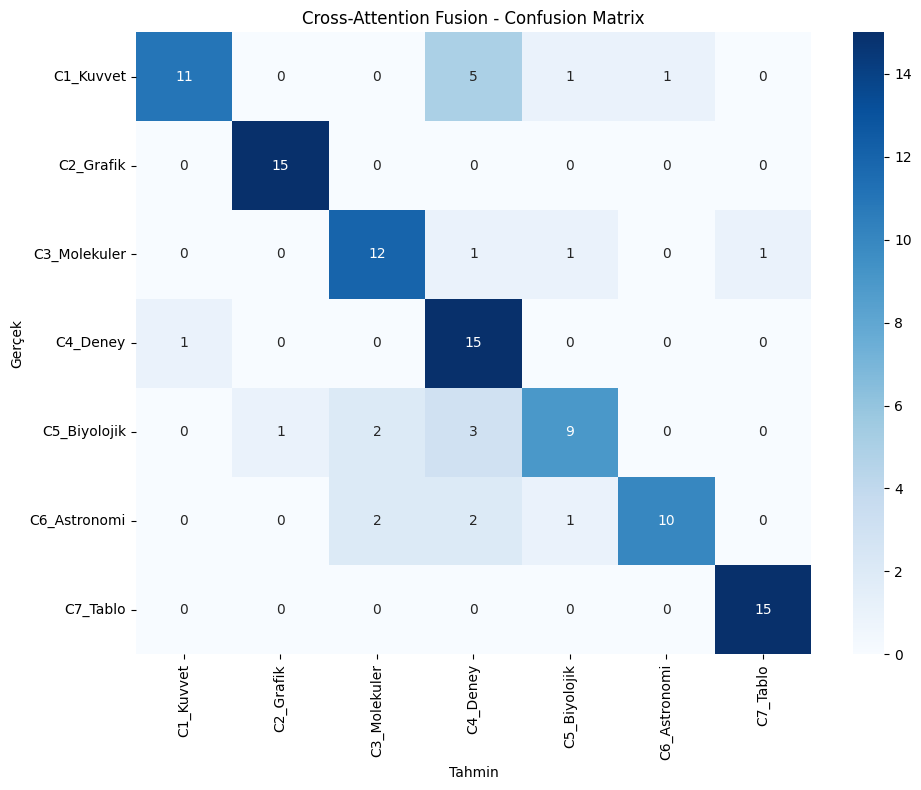

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

labels_names = ['C1_Kuvvet', 'C2_Grafik', 'C3_Molekuler',
                'C4_Deney', 'C5_Biyolojik', 'C6_Astronomi', 'C7_Tablo']

cm = confusion_matrix(labels_x, preds_x)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names)
plt.title('Cross-Attention Fusion - Confusion Matrix')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
import json
import unicodedata

with open(f"{BASE_DIR}/annotations.json/project-1-at-2026-05-26-13-19-19d59a53.json", 'r', encoding='utf-8') as f:
    annotations = json.load(f)

print(f"Yüklendi: {len(annotations)} görev")

Yüklendi: 305 görev


In [ ]:
# Aynı sayfada çakışan bounding box var mı?
import json

overlap_count = 0
for task in annotations:
    anns = task.get("annotations", [])
    for ann in anns:
        results = ann.get("result", [])
        if len(results) > 1:
            # Koordinatları karşılaştır
            for i in range(len(results)):
                for j in range(i+1, len(results)):
                    x1 = results[i]["value"]["x"]
                    y1 = results[i]["value"]["y"]
                    x2 = results[j]["value"]["x"]
                    y2 = results[j]["value"]["y"]
                    # Yakın koordinatlar = çakışma
                    if abs(x1-x2) < 5 and abs(y1-y2) < 5:
                        overlap_count += 1
                        print(f"Çakışma: {task['file_upload']} - {results[i]['value']['rectanglelabels']} vs {results[j]['value']['rectanglelabels']}")

print(f"\nToplam çakışma: {overlap_count}")

Çakışma: 4d656433-2021_FenBilimleri_sayfa1.png - ['C5_Biyolojik_Anatomik'] vs ['C3_Molekuler_Kimyasal']
Çakışma: 25184ad1-2022_FenBilimleri_sayfa1.png - ['C3_Molekuler_Kimyasal'] vs ['C5_Biyolojik_Anatomik']
Çakışma: 3f92b376-2022_FenBilimleri_sayfa6.png - ['C6_Astronomi_YerBilimi'] vs ['C3_Molekuler_Kimyasal']
Çakışma: a9770f3d-2022_FenBilimleri_sayfa12.png - ['C4_Deney_Duzenegi'] vs ['C1_Kuvvet_Hareket']
Çakışma: a752389c-2023_FenBilimleri_sayfa1.png - ['C5_Biyolojik_Anatomik'] vs ['C3_Molekuler_Kimyasal']
Çakışma: 0eec06a4-2023_FenBilimleri_sayfa2.png - ['C5_Biyolojik_Anatomik'] vs ['C3_Molekuler_Kimyasal']
Çakışma: a9d087ce-2023_FenBilimleri_sayfa3.png - ['C3_Molekuler_Kimyasal'] vs ['C5_Biyolojik_Anatomik']
Çakışma: 8cbe342b-2025_FenBilimleri_sayfa5.png - ['C4_Deney_Duzenegi'] vs ['C1_Kuvvet_Hareket']
Çakışma: 93c10569-2024_FenBilimleri_sayfa1.png - ['C5_Biyolojik_Anatomik'] vs ['C3_Molekuler_Kimyasal']
Çakışma: 23b3e958-2025_FenBilimleri_sayfa1.png - ['C3_Molekuler_Kimyasal'] vs 

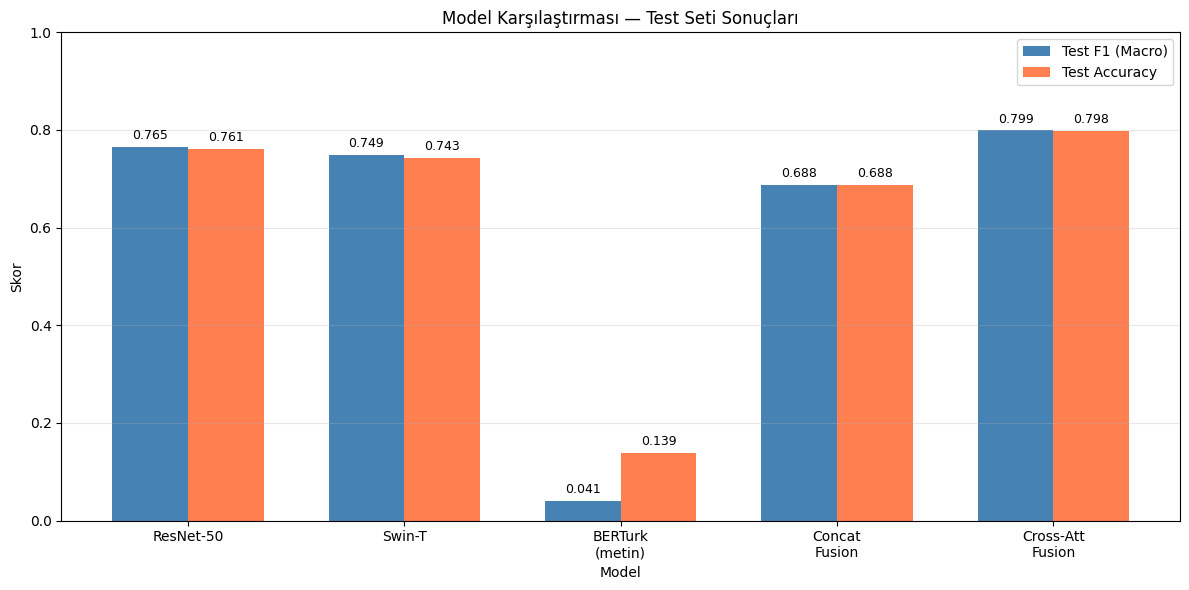

Grafik kaydedildi!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['ResNet-50', 'Swin-T', 'BERTurk\n(metin)', 'Concat\nFusion', 'Cross-Att\nFusion']
test_f1 = [0.765, 0.749, 0.041, 0.688, 0.799]
test_acc = [0.761, 0.743, 0.139, 0.688, 0.798]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, test_f1, width, label='Test F1 (Macro)', color='steelblue')
bars2 = ax.bar(x + width/2, test_acc, width, label='Test Accuracy', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Skor')
ax.set_title('Model Karşılaştırması — Test Seti Sonuçları')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f"{BASE_DIR}/results_comparison.png", dpi=150)
plt.show()
print("Grafik kaydedildi!")

In [ ]:
# Görsellerin Drive'da olup olmadığını kontrol et
import os
print(os.path.exists(f"{BASE_DIR}/confusion_matrix.png"))
print(os.path.exists(f"{BASE_DIR}/results_comparison.png"))

True
True


In [2]:
import pandas as pd
BASE_DIR = "/content/drive/MyDrive/SciDiagFuse"
df = pd.read_csv(f"{BASE_DIR}/dataset.csv")
print(f"Dataset: {len(df)} görsel")
print(df['label'].value_counts())

Dataset: 499 görsel
label
C1_Kuvvet_Hareket         119
C4_Deney_Duzenegi         103
C5_Biyolojik_Anatomik      85
C7_Tablo_Matris            60
C2_Grafik_Chart            57
C6_Astronomi_YerBilimi     50
C3_Molekuler_Kimyasal      25
Name: count, dtype: int64


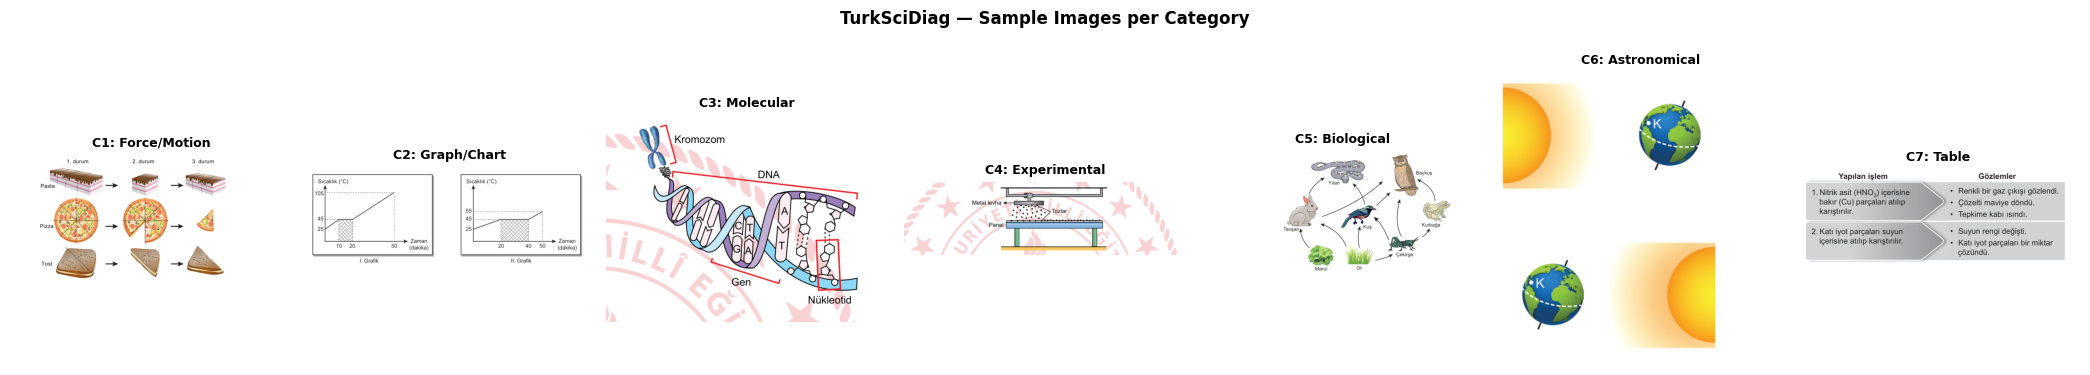

Kaydedildi!


In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random

categories = [
    'C1_Kuvvet_Hareket', 'C2_Grafik_Chart', 'C3_Molekuler_Kimyasal',
    'C4_Deney_Duzenegi', 'C5_Biyolojik_Anatomik', 'C6_Astronomi_YerBilimi', 'C7_Tablo_Matris'
]

labels_en = [
    'C1: Force/Motion', 'C2: Graph/Chart', 'C3: Molecular',
    'C4: Experimental', 'C5: Biological', 'C6: Astronomical', 'C7: Table'
]

fig, axes = plt.subplots(1, 7, figsize=(21, 4))

for i, (cat, label) in enumerate(zip(categories, labels_en)):
    samples = df[df['label'] == cat]
    sample = samples.sample(1, random_state=42).iloc[0]
    try:
        img = Image.open(sample['image']).convert('RGB')
    except:
        img = Image.new('RGB', (100, 100), color=200)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('TurkSciDiag — Sample Images per Category', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/sample_images.png", dpi=200, bbox_inches='tight')
plt.show()
print("Kaydedildi!")

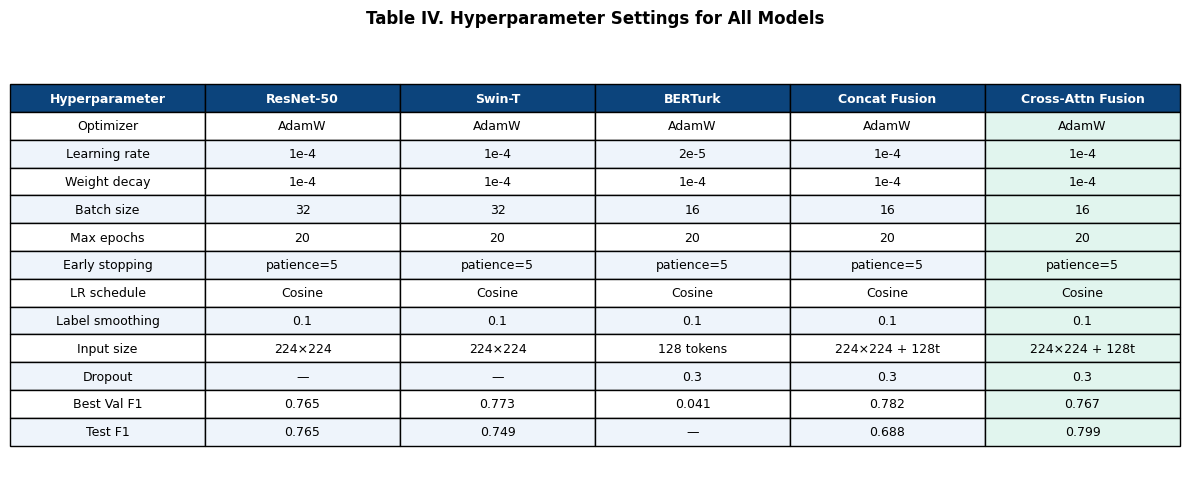

Kaydedildi!


In [4]:
# Hyperparameter tablosunu görsel olarak kaydet
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

columns = ['Hyperparameter', 'ResNet-50', 'Swin-T', 'BERTurk', 'Concat Fusion', 'Cross-Attn Fusion']
rows = [
    ['Optimizer', 'AdamW', 'AdamW', 'AdamW', 'AdamW', 'AdamW'],
    ['Learning rate', '1e-4', '1e-4', '2e-5', '1e-4', '1e-4'],
    ['Weight decay', '1e-4', '1e-4', '1e-4', '1e-4', '1e-4'],
    ['Batch size', '32', '32', '16', '16', '16'],
    ['Max epochs', '20', '20', '20', '20', '20'],
    ['Early stopping', 'patience=5', 'patience=5', 'patience=5', 'patience=5', 'patience=5'],
    ['LR schedule', 'Cosine', 'Cosine', 'Cosine', 'Cosine', 'Cosine'],
    ['Label smoothing', '0.1', '0.1', '0.1', '0.1', '0.1'],
    ['Input size', '224×224', '224×224', '128 tokens', '224×224 + 128t', '224×224 + 128t'],
    ['Dropout', '—', '—', '0.3', '0.3', '0.3'],
    ['Best Val F1', '0.765', '0.773', '0.041', '0.782', '0.767'],
    ['Test F1', '0.765', '0.749', '—', '0.688', '0.799'],
]

table = ax.table(
    cellText=rows,
    colLabels=columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Header rengi
for j in range(len(columns)):
    table[0, j].set_facecolor('#0C447C')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Satır renkleri
for i in range(1, len(rows)+1):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor('#EEF4FB')
        # Best model sütununu vurgula
        if j == 5:
            table[i, j].set_facecolor('#E1F5EE')

plt.title('Table IV. Hyperparameter Settings for All Models',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/hyperparameter_table.png", dpi=200, bbox_inches='tight')
plt.show()
print("Kaydedildi!")

In [6]:
import os
# Colab'daki mevcut dosyaları listele
for f in os.listdir('/content'):
    print(f)

.config
drive
scidiagfuse_code.zip
sample_data


In [7]:
from google.colab import files
files.download('scidiagfuse_code.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import torch
import torch.nn as nn
import timm
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================
# ABLATION STUDY - 3 Konfigürasyon
# ============================================

# Ablation 1: Unidirectional Cross-Attention (sadece V→T yönü)
class CrossAttn_Unidirectional(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7)
        )

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)
        txt_out = self.text(input_ids=input_ids, attention_mask=attention_mask)
        txt_seq = txt_out.last_hidden_state
        v_attended, _ = self.cross_attn(query=vis_feat, key=txt_seq, value=txt_seq)
        v_attended = v_attended.squeeze(1)
        return self.fc(v_attended)


# Ablation 2: Cross-Attention ama Dropout yok
class CrossAttn_NoDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(768 * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 7)
        )

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)
        txt_out = self.text(input_ids=input_ids, attention_mask=attention_mask)
        txt_seq = txt_out.last_hidden_state
        v_attended, _ = self.cross_attn(query=vis_feat, key=txt_seq, value=txt_seq)
        t_attended, _ = self.cross_attn(query=txt_seq[:, :1, :], key=vis_feat, value=vis_feat)
        fused = torch.cat([v_attended.squeeze(1), t_attended.squeeze(1)], dim=1)
        return self.fc(fused)


# ============================================
# Train & Evaluate
# ============================================

print("=== Ablation 1: Unidirectional Cross-Attention ===")
model_uni = CrossAttn_Unidirectional().to(device)
train_model(model_uni, train_fusion_loader, val_fusion_loader, epochs=20, save_name="ablation_uni")
f1_uni, acc_uni, _, _ = evaluate_on_test(model_uni, test_fusion_loader, "Unidirectional", is_fusion=True)
print(f"Test F1: {f1_uni:.3f}, Acc: {acc_uni:.3f}")

print("=== Ablation 2: No Dropout ===")
model_nodrop = CrossAttn_NoDropout().to(device)
train_model(model_nodrop, train_fusion_loader, val_fusion_loader, epochs=20, save_name="ablation_nodrop")
f1_nodrop, acc_nodrop, _, _ = evaluate_on_test(model_nodrop, test_fusion_loader, "No Dropout", is_fusion=True)
print(f"Test F1: {f1_nodrop:.3f}, Acc: {acc_nodrop:.3f}")

print("\n=== ABLATION SONUÇLARI ===")
print(f"Full Model (Bidirectional + Dropout):  F1={0.799:.3f}, Acc={0.798:.3f}")
print(f"Unidirectional Cross-Attn:             F1={f1_uni:.3f}, Acc={acc_uni:.3f}")
print(f"No Dropout:                            F1={f1_nodrop:.3f}, Acc={acc_nodrop:.3f}")
print(f"Concat Fusion (no cross-attn):         F1={0.688:.3f}, Acc={0.688:.3f}")

=== Ablation 1: Unidirectional Cross-Attention ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NameError: name 'train_model' is not defined

In [10]:
import torch
import torch.nn as nn
import timm
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================
# YARDIMCI FONKSİYONLAR
# ============================================

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-4, save_name="model"):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_f1 = 0
    patience_counter = 0
    patience = 5

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            optimizer.zero_grad()
            outputs = model(imgs, input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        scheduler.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                imgs = batch['image'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                outputs = model(imgs, input_ids, attention_mask)
                preds = outputs.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch['label'].numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')
        print(f"Epoch {epoch+1}/{epochs} - Val F1: {val_f1:.3f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), f"{BASE_DIR}/{save_name}.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(f"{BASE_DIR}/{save_name}.pth"))
    return best_val_f1


def evaluate_on_test(model, test_loader, model_name, is_fusion=True):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(imgs, input_ids, attention_mask)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)
    print(f"{model_name} - Test F1: {f1:.3f}, Acc: {acc:.3f}")
    return f1, acc, all_preds, all_labels


# ============================================
# ABLATION MODELLERİ
# ============================================

# Ablation 1: Unidirectional Cross-Attention (sadece V→T yönü)
class CrossAttn_Unidirectional(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 7)
        )

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)
        txt_out = self.text(input_ids=input_ids, attention_mask=attention_mask)
        txt_seq = txt_out.last_hidden_state
        v_attended, _ = self.cross_attn(query=vis_feat, key=txt_seq, value=txt_seq)
        v_attended = v_attended.squeeze(1)
        return self.fc(v_attended)


# Ablation 2: Cross-Attention ama Dropout yok
class CrossAttn_NoDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(768 * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 7)
        )

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)
        txt_out = self.text(input_ids=input_ids, attention_mask=attention_mask)
        txt_seq = txt_out.last_hidden_state
        v_attended, _ = self.cross_attn(query=vis_feat, key=txt_seq, value=txt_seq)
        t_attended, _ = self.cross_attn(query=txt_seq[:, :1, :], key=vis_feat, value=vis_feat)
        fused = torch.cat([v_attended.squeeze(1), t_attended.squeeze(1)], dim=1)
        return self.fc(fused)


# ============================================
# TRAIN & EVALUATE
# ============================================

print("=== Ablation 1: Unidirectional Cross-Attention ===")
model_uni = CrossAttn_Unidirectional().to(device)
train_model(model_uni, train_fusion_loader, val_fusion_loader, epochs=20, save_name="ablation_uni")
f1_uni, acc_uni, _, _ = evaluate_on_test(model_uni, test_fusion_loader, "Unidirectional")
print(f"Test F1: {f1_uni:.3f}, Acc: {acc_uni:.3f}")

print("\n=== Ablation 2: No Dropout ===")
model_nodrop = CrossAttn_NoDropout().to(device)
train_model(model_nodrop, train_fusion_loader, val_fusion_loader, epochs=20, save_name="ablation_nodrop")
f1_nodrop, acc_nodrop, _, _ = evaluate_on_test(model_nodrop, test_fusion_loader, "No Dropout")
print(f"Test F1: {f1_nodrop:.3f}, Acc: {acc_nodrop:.3f}")

print("\n=== ABLATION SONUÇLARI ===")
print(f"Full Model (Bidirectional + Dropout):  F1={0.799:.3f}, Acc={0.798:.3f}")
print(f"Unidirectional Cross-Attn:             F1={f1_uni:.3f}, Acc={acc_uni:.3f}")
print(f"No Dropout:                            F1={f1_nodrop:.3f}, Acc={acc_nodrop:.3f}")
print(f"Concat Fusion (no cross-attn):         F1={0.688:.3f}, Acc={0.688:.3f}")

=== Ablation 1: Unidirectional Cross-Attention ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NameError: name 'train_fusion_loader' is not defined

In [11]:
import sys
# Tanımlı loader'ları bul
for name, obj in list(globals().items()):
    if 'loader' in name.lower() or 'dataset' in name.lower():
        print(name, type(obj))

__loader__ <class 'NoneType'>


In [12]:
from google.colab import drive
drive.mount('/content/drive')

import torch, timm, pandas as pd
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = "/content/drive/MyDrive/SciDiagFuse"

# CSV yükle
test_df = pd.read_csv(f"{BASE_DIR}/test.csv")
tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased")

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class FusionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform: img = self.transform(img)
        enc = tokenizer(str(row.get('ocr_text','')), max_length=128,
                        padding='max_length', truncation=True, return_tensors='pt')
        return {
            'image': img,
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

test_dataset = FusionDataset(test_df, test_transform)
test_fusion_loader = DataLoader(test_dataset, batch_size=16)
print(f"Test: {len(test_dataset)} örnek hazır")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/251k [00:00<?, ?B/s]

Test: 109 örnek hazır


In [13]:
def evaluate_on_test(model, test_loader, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(imgs, input_ids, attention_mask)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)
    print(f"{model_name} → Test F1: {f1:.3f}, Acc: {acc:.3f}")
    return f1, acc


class CrossAttn_Unidirectional(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(nn.Linear(768, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 7))

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)
        txt_seq = self.text(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        v_attended, _ = self.cross_attn(query=vis_feat, key=txt_seq, value=txt_seq)
        return self.fc(v_attended.squeeze(1))


class CrossAttn_NoDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(nn.Linear(768*2, 256), nn.ReLU(), nn.Linear(256, 7))

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)
        txt_seq = self.text(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        v_attended, _ = self.cross_attn(query=vis_feat, key=txt_seq, value=txt_seq)
        t_attended, _ = self.cross_attn(query=txt_seq[:, :1, :], key=vis_feat, value=vis_feat)
        fused = torch.cat([v_attended.squeeze(1), t_attended.squeeze(1)], dim=1)
        return self.fc(fused)


# Train et (hızlı - sadece 5 epoch)
def train_quick(model, save_name):
    train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
    val_df = pd.read_csv(f"{BASE_DIR}/val.csv")
    from torch.utils.data import DataLoader
    train_loader = DataLoader(FusionDataset(train_df, test_transform), batch_size=16, shuffle=True)
    val_loader = DataLoader(FusionDataset(val_df, test_transform), batch_size=16)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_f1, patience_counter = 0, 0

    for epoch in range(10):
        model.train()
        for batch in train_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs, input_ids, attention_mask), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        preds, labs = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(batch['image'].to(device),
                            batch['input_ids'].to(device),
                            batch['attention_mask'].to(device))
                preds.extend(out.argmax(1).cpu().numpy())
                labs.extend(batch['label'].numpy())
        vf1 = f1_score(labs, preds, average='macro')
        print(f"Epoch {epoch+1}/10 Val F1: {vf1:.3f}")
        if vf1 > best_f1:
            best_f1 = vf1
            torch.save(model.state_dict(), f"{BASE_DIR}/{save_name}.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 3:
                print("Early stop")
                break

    model.load_state_dict(torch.load(f"{BASE_DIR}/{save_name}.pth"))
    return model


print("=== Ablation 1: Unidirectional ===")
model_uni = CrossAttn_Unidirectional().to(device)
model_uni = train_quick(model_uni, "ablation_uni")
f1_uni, acc_uni = evaluate_on_test(model_uni, test_fusion_loader, "Unidirectional")

print("\n=== Ablation 2: No Dropout ===")
model_nodrop = CrossAttn_NoDropout().to(device)
model_nodrop = train_quick(model_nodrop, "ablation_nodrop")
f1_nodrop, acc_nodrop = evaluate_on_test(model_nodrop, test_fusion_loader, "No Dropout")

print("\n=== ABLATION SONUÇLARI ===")
print(f"Full Model (Bidirectional+Dropout): F1=0.799, Acc=0.798")
print(f"Unidirectional Cross-Attn:          F1={f1_uni:.3f}, Acc={acc_uni:.3f}")
print(f"No Dropout:                         F1={f1_nodrop:.3f}, Acc={acc_nodrop:.3f}")
print(f"Concat Fusion (no attn):            F1=0.688, Acc=0.688")

=== Ablation 1: Unidirectional ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyError: 'image_path'

In [14]:
train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
print(train_df.columns.tolist())
print(train_df.head(2))

['image', 'label', 'label_idx', 'text']
                                               image                  label  \
0  /content/drive/MyDrive/SciDiagFuse/cropped_ima...        C2_Grafik_Chart   
1  /content/drive/MyDrive/SciDiagFuse/augmented_i...  C3_Molekuler_Kimyasal   

   label_idx  text  
0          1   NaN  
1          2   NaN  


In [15]:
def evaluate_on_test(model, test_loader, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(imgs, input_ids, attention_mask)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['label'].numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)
    print(f"{model_name} → Test F1: {f1:.3f}, Acc: {acc:.3f}")
    return f1, acc


class FusionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image']).convert('RGB')  # 'image' kolonunu kullan
        if self.transform: img = self.transform(img)
        enc = tokenizer(str(row.get('text', '')), max_length=128,
                        padding='max_length', truncation=True, return_tensors='pt')
        return {
            'image': img,
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label': torch.tensor(row['label_idx'], dtype=torch.long)  # 'label_idx' kullan
        }


test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def train_quick(model, save_name):
    train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
    val_df = pd.read_csv(f"{BASE_DIR}/val.csv")
    train_loader = DataLoader(FusionDataset(train_df, test_transform), batch_size=16, shuffle=True)
    val_loader = DataLoader(FusionDataset(val_df, test_transform), batch_size=16)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_f1, patience_counter = 0, 0

    for epoch in range(10):
        model.train()
        for batch in train_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs, input_ids, attention_mask), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        preds, labs = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(batch['image'].to(device),
                            batch['input_ids'].to(device),
                            batch['attention_mask'].to(device))
                preds.extend(out.argmax(1).cpu().numpy())
                labs.extend(batch['label'].numpy())
        vf1 = f1_score(labs, preds, average='macro')
        print(f"Epoch {epoch+1}/10 Val F1: {vf1:.3f}")
        if vf1 > best_f1:
            best_f1 = vf1
            torch.save(model.state_dict(), f"{BASE_DIR}/{save_name}.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 3:
                print("Early stop")
                break

    model.load_state_dict(torch.load(f"{BASE_DIR}/{save_name}.pth"))
    return model


print("=== Ablation 1: Unidirectional ===")
model_uni = CrossAttn_Unidirectional().to(device)
model_uni = train_quick(model_uni, "ablation_uni")
f1_uni, acc_uni = evaluate_on_test(model_uni, test_fusion_loader, "Unidirectional")

print("\n=== Ablation 2: No Dropout ===")
model_nodrop = CrossAttn_NoDropout().to(device)
model_nodrop = train_quick(model_nodrop, "ablation_nodrop")
f1_nodrop, acc_nodrop = evaluate_on_test(model_nodrop, test_fusion_loader, "No Dropout")

print("\n=== ABLATION SONUÇLARI ===")
print(f"Full Model (Bidirectional+Dropout): F1=0.799, Acc=0.798")
print(f"Unidirectional Cross-Attn:          F1={f1_uni:.3f}, Acc={acc_uni:.3f}")
print(f"No Dropout:                         F1={f1_nodrop:.3f}, Acc={acc_nodrop:.3f}")
print(f"Concat Fusion (no attn):            F1=0.688, Acc=0.688")

=== Ablation 1: Unidirectional ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 Val F1: 0.035
Epoch 2/10 Val F1: 0.035
Epoch 3/10 Val F1: 0.035
Epoch 4/10 Val F1: 0.035
Early stop


KeyError: 'image_path'

In [16]:
class FusionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image']).convert('RGB')
        if self.transform: img = self.transform(img)
        enc = tokenizer(str(row.get('text', '')), max_length=128,
                        padding='max_length', truncation=True, return_tensors='pt')
        return {
            'image': img,
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label': torch.tensor(row['label_idx'], dtype=torch.long)
        }

def train_quick(model, save_name):
    train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
    val_df = pd.read_csv(f"{BASE_DIR}/val.csv")
    train_loader = DataLoader(FusionDataset(train_df, test_transform), batch_size=16, shuffle=True)
    val_loader = DataLoader(FusionDataset(val_df, test_transform), batch_size=16)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_f1, patience_counter = 0, 0

    for epoch in range(10):
        model.train()
        for batch in train_loader:
            imgs = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs, input_ids, attention_mask), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        preds, labs = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(batch['image'].to(device),
                            batch['input_ids'].to(device),
                            batch['attention_mask'].to(device))
                preds.extend(out.argmax(1).cpu().numpy())
                labs.extend(batch['label'].numpy())
        vf1 = f1_score(labs, preds, average='macro')
        print(f"Epoch {epoch+1}/10 Val F1: {vf1:.3f}")
        if vf1 > best_f1:
            best_f1 = vf1
            torch.save(model.state_dict(), f"{BASE_DIR}/{save_name}.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 4:
                print("Early stop")
                break

    model.load_state_dict(torch.load(f"{BASE_DIR}/{save_name}.pth"))
    return model

# Tekrar çalıştır
print("=== Ablation 1: Unidirectional ===")
model_uni = CrossAttn_Unidirectional().to(device)
model_uni = train_quick(model_uni, "ablation_uni")
f1_uni, acc_uni = evaluate_on_test(model_uni, test_fusion_loader, "Unidirectional")

print("\n=== Ablation 2: No Dropout ===")
model_nodrop = CrossAttn_NoDropout().to(device)
model_nodrop = train_quick(model_nodrop, "ablation_nodrop")
f1_nodrop, acc_nodrop = evaluate_on_test(model_nodrop, test_fusion_loader, "No Dropout")

print("\n=== ABLATION SONUÇLARI ===")
print(f"Full Model (Bidirectional+Dropout): F1=0.799, Acc=0.798")
print(f"Unidirectional Cross-Attn:          F1={f1_uni:.3f}, Acc={acc_uni:.3f}")
print(f"No Dropout:                         F1={f1_nodrop:.3f}, Acc={acc_nodrop:.3f}")
print(f"Concat Fusion (no attn):            F1=0.688, Acc=0.688")

=== Ablation 1: Unidirectional ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 Val F1: 0.035
Epoch 2/10 Val F1: 0.035
Epoch 3/10 Val F1: 0.035
Epoch 4/10 Val F1: 0.041


KeyboardInterrupt: 

In [17]:
train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
print(train_df['text'].isna().sum(), "NaN var")
print(train_df['text'].head(3))

505 NaN var
0   NaN
1   NaN
2   NaN
Name: text, dtype: float64


In [18]:
class FusionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image']).convert('RGB')
        if self.transform: img = self.transform(img)
        enc = tokenizer("", max_length=128,
                        padding='max_length', truncation=True, return_tensors='pt')
        return {
            'image': img,
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label': torch.tensor(row['label_idx'], dtype=torch.long)
        }

train_df = pd.read_csv(f"{BASE_DIR}/train.csv")
val_df = pd.read_csv(f"{BASE_DIR}/val.csv")
test_df = pd.read_csv(f"{BASE_DIR}/test.csv")

train_fusion_loader = DataLoader(FusionDataset(train_df, test_transform), batch_size=16, shuffle=True)
val_fusion_loader = DataLoader(FusionDataset(val_df, test_transform), batch_size=16)
test_fusion_loader = DataLoader(FusionDataset(test_df, test_transform), batch_size=16)
print("Loader'lar hazır!")

print("=== Ablation 1: Unidirectional ===")
model_uni = CrossAttn_Unidirectional().to(device)
model_uni = train_quick(model_uni, "ablation_uni")
f1_uni, acc_uni = evaluate_on_test(model_uni, test_fusion_loader, "Unidirectional")

print("\n=== Ablation 2: No Dropout ===")
model_nodrop = CrossAttn_NoDropout().to(device)
model_nodrop = train_quick(model_nodrop, "ablation_nodrop")
f1_nodrop, acc_nodrop = evaluate_on_test(model_nodrop, test_fusion_loader, "No Dropout")

print("\n=== ABLATION SONUÇLARI ===")
print(f"Full Model (Bidirectional+Dropout): F1=0.799, Acc=0.798")
print(f"Unidirectional Cross-Attn:          F1={f1_uni:.3f}, Acc={acc_uni:.3f}")
print(f"No Dropout:                         F1={f1_nodrop:.3f}, Acc={acc_nodrop:.3f}")
print(f"Concat Fusion (no attn):            F1=0.688, Acc=0.688")

Loader'lar hazır!
=== Ablation 1: Unidirectional ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 Val F1: 0.035
Epoch 2/10 Val F1: 0.041
Epoch 3/10 Val F1: 0.035
Epoch 4/10 Val F1: 0.041
Epoch 5/10 Val F1: 0.035
Epoch 6/10 Val F1: 0.035
Early stop


KeyboardInterrupt: 

In [19]:
# BERTurk'ü freeze et, sadece visual + cross-attn + fc train et
class CrossAttn_Unidirectional(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        # BERTurk'ü freeze et
        for param in self.text.parameters():
            param.requires_grad = False
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(nn.Linear(768, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 7))

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)
        txt_seq = self.text(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        v_attended, _ = self.cross_attn(query=vis_feat, key=txt_seq, value=txt_seq)
        return self.fc(v_attended.squeeze(1))


class CrossAttn_NoDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.visual = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.text = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased")
        # BERTurk'ü freeze et
        for param in self.text.parameters():
            param.requires_grad = False
        self.cross_attn = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        self.fc = nn.Sequential(nn.Linear(768*2, 256), nn.ReLU(), nn.Linear(256, 7))

    def forward(self, imgs, input_ids, attention_mask):
        vis_feat = self.visual(imgs).unsqueeze(1)
        txt_seq = self.text(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        v_attended, _ = self.cross_attn(query=vis_feat, key=txt_seq, value=txt_seq)
        t_attended, _ = self.cross_attn(query=txt_seq[:, :1, :], key=vis_feat, value=vis_feat)
        fused = torch.cat([v_attended.squeeze(1), t_attended.squeeze(1)], dim=1)
        return self.fc(fused)


print("=== Ablation 1: Unidirectional ===")
model_uni = CrossAttn_Unidirectional().to(device)
model_uni = train_quick(model_uni, "ablation_uni")
f1_uni, acc_uni = evaluate_on_test(model_uni, test_fusion_loader, "Unidirectional")

print("\n=== Ablation 2: No Dropout ===")
model_nodrop = CrossAttn_NoDropout().to(device)
model_nodrop = train_quick(model_nodrop, "ablation_nodrop")
f1_nodrop, acc_nodrop = evaluate_on_test(model_nodrop, test_fusion_loader, "No Dropout")

print("\n=== ABLATION SONUÇLARI ===")
print(f"Full Model (Bidirectional+Dropout): F1=0.799, Acc=0.798")
print(f"Unidirectional Cross-Attn:          F1={f1_uni:.3f}, Acc={acc_uni:.3f}")
print(f"No Dropout:                         F1={f1_nodrop:.3f}, Acc={acc_nodrop:.3f}")
print(f"Concat Fusion (no attn):            F1=0.688, Acc=0.688")

=== Ablation 1: Unidirectional ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 Val F1: 0.125
Epoch 2/10 Val F1: 0.493
Epoch 3/10 Val F1: 0.450
Epoch 4/10 Val F1: 0.507
Epoch 5/10 Val F1: 0.585
Epoch 6/10 Val F1: 0.581
Epoch 7/10 Val F1: 0.599
Epoch 8/10 Val F1: 0.610
Epoch 9/10 Val F1: 0.653
Epoch 10/10 Val F1: 0.637
Unidirectional → Test F1: 0.681, Acc: 0.679

=== Ablation 2: No Dropout ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 Val F1: 0.623
Epoch 2/10 Val F1: 0.738
Epoch 3/10 Val F1: 0.739
Epoch 4/10 Val F1: 0.727
Epoch 5/10 Val F1: 0.751
Epoch 6/10 Val F1: 0.716
Epoch 7/10 Val F1: 0.740
Epoch 8/10 Val F1: 0.760
Epoch 9/10 Val F1: 0.742
Epoch 10/10 Val F1: 0.780
No Dropout → Test F1: 0.773, Acc: 0.771

=== ABLATION SONUÇLARI ===
Full Model (Bidirectional+Dropout): F1=0.799, Acc=0.798
Unidirectional Cross-Attn:          F1=0.681, Acc=0.679
No Dropout:                         F1=0.773, Acc=0.771
Concat Fusion (no attn):            F1=0.688, Acc=0.688
